# Project: AI-Driven Water Quality Prediction and Monitoring: A Unified Framework for Compliance Intelligence

#### DATE: Spring 2026
----

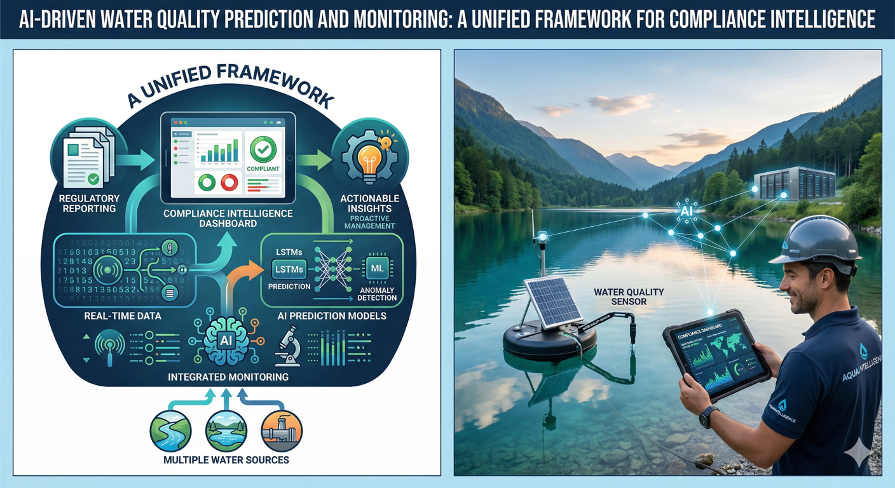


----

# Comprehensive Water Quality Modeling Notebook

This notebook includes:

1. **EDA before preprocessing**
2. **Preprocessing**
   - invalid value cleanup
   - optional hydrologic imputation
   - optional outlier handling
   - **state-aware compliance flag** creation
3. **EDA after preprocessing**
4. **Tabular forecasting track**
   - Linear Regression
   - Random Forest
   - XGBoost
   - CatBoost (optional)
   - LightGBM (optional)
   - weighted ensemble
5. **Deep learning forecasting track**
   - LSTM 
6. **RQ2 / RQ3 / RQ4 / RQ5 sections**
7. **Next-observation sequence forecasting setup**
   - LSTM next-observation (optional)
   - TCN next-observation (optional)

Main data path:

```python
DATA_PATH = '/content/drive/MyDrive/WQP Modelling/final_dataset_enriched.parquet'
```

### Project Overview
This project is for building a multi-state water-quality dataset for modeling and research.

At a high level, it uses the EPA Water Quality Portal as the main source of truth, pulling stream monitoring data from CA, OR, WA, NV, and AZ for 2015-01-01 through 2024-12-31. It focuses on three measurements: pH, turbidity, and dissolved oxygen. The output is a cleaned, daily, site-level dataset that can be used for regression, explainability, anomaly detection, classification, and model comparison.

The main flow is:

Pull raw WQP measurements

src/wqp.py queries Water Quality Portal result and station APIs, normalizes state codes/dates, standardizes columns, and handles characteristic synonyms.

Build the core dataset

src/build_dataset.py drives the pipeline using config/config.multistate.yaml. It saves data/raw/wqp_long.csv, data/interim/wqp_wide.csv, station metadata, and final CSV/parquet outputs.

Add modeling features

src/features.py adds calendar features, lag features, rolling means, and a turbidity compliance flag where turbidity exceeds 5.0.

Optionally enrich with USGS data

src/enrich_with_usgs.py and src/usgs_enrichment.py add USGS daily values like discharge, water temperature, and gage height for sites whose IDs map to USGS stations.

The current generated dataset is already substantial: 144,849 rows across 2,236 monitoring sites, according to data/processed/extraction_summary.json. The enriched version preserves the same row count and adds USGS fields where available.

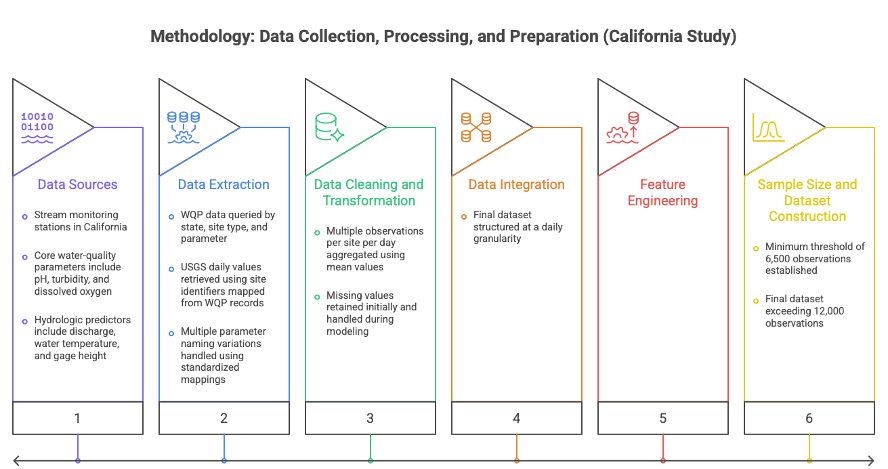

 ### Methodology for Data Collection, Processing, and Preparation"

The above shows the workflow that progresses from raw data acquisition to a fully processed dataset, ensuring consistency, scalability, and suitability for machine learning and deep learning applications.

# Data Dictionary for AI-Driven Water Quality Prediction and Monitoring Dataset

| Variable Name | Definition | Datatype | Allowed Values/Range | Missing Values Handling | Notes |
|---|---|---|---|---|---|
| `site_id` | Unique monitoring site identifier from WQP/USGS source records. | String / object | Valid station/site identifier | Rows retained; missing site IDs to be excluded from modeling because site/date grouping is required. | Used for grouping time-series observations and creating lag/rolling features. |
| `date` | Sampling or observation date at daily granularity. | Date / datetime | 2015-01-01 to 2024-12-31 | Invalid or missing dates to be removed. | Used for temporal ordering, trend analysis, lags, rolling means, and forecasting. |
| `turbidity` | Measure of water clarity and suspended particles in water. | Continuous numeric | ≥ 0 NTU; extreme values reviewed as potential events or outliers | Missing values retained during raw processing; rows with missing active target are excluded for target-specific modeling. | Primary target variable for RQ1/RQ5; also used in RQ3 anomaly detection and RQ4 operational-risk flagging. |
| `ph` | Measure of acidity or alkalinity. | Continuous numeric | 0–14; values outside range treated as chemically invalid | Invalid values removed or set to missing; missing values handled by target-specific exclusion or imputation. | Secondary target variable; dimensionless. |
| `dissolved_oxygen` | Oxygen concentration in water. | Continuous numeric | Typically ≥ 0 mg/L; unusually high values reviewed | Missing values retained initially; handled through target-specific exclusion or imputation. | Secondary target variable; supports multivariate modeling and anomaly detection. |
| `discharge` | Stream flow rate from USGS enrichment. | Continuous numeric | ≥ 0 ft³/s (cfs) | Missing values expected due to partial USGS coverage; used only in enriched Dataset B or imputed where appropriate. | Predictor for RQ2 and RQ4; important hydrologic driver. |
| `water_temp` | Water temperature from USGS enrichment. | Continuous numeric | Typically -5°C to 50°C; values checked for Celsius consistency | Missing values expected; used in enriched Dataset B or imputed where appropriate. | Predictor for RQ2/RQ4; thermal condition of water. |
| `gage_height` | Water level relative to a station datum. | Continuous numeric | Feet; plausible values depend on station | Missing values expected; treated as optional predictor. | Optional USGS predictor; lower coverage than discharge and temperature. |
| `site_name` | Descriptive name of monitoring location. | String / object | Valid station/site name | Retained for metadata; not used directly in numeric modeling. | Useful for interpretability, auditing, and reporting. |
| `site_type_name` | Type of monitoring site or waterbody context. | String / categorical | Examples: Stream, Canal, Reservoir, etc. | Retained; may be encoded if used as a categorical feature. | Supports site-context interpretation. |
| `huc8` | Hydrologic Unit Code identifying watershed region. | Numeric/string categorical | Valid HUC8 code | Missing values retained; may be excluded or encoded depending on modeling task. | Useful for watershed grouping and spatial context. |
| `state_code` | State identifier for monitoring location. | Integer / categorical | State codes for CA, OR, WA, NV, AZ | Missing values should be reviewed; rows retained if site/date/target are valid. | May be used for state-aware modeling or stratified analysis. |
| `county_code` | County identifier for monitoring location. | Integer / categorical | Valid county code | Missing values retained unless required for spatial analysis. | Metadata; generally excluded from baseline numeric models unless encoded. |
| `organization_name` | Organization responsible for data collection. | String / categorical | Valid agency/organization name | Retained for metadata and auditability. | Not used directly in core numeric modeling unless encoded. |
| `month` | Calendar month extracted from date. | Integer | 1–12 | Derived from date; missing only if date missing. | Time-based seasonality feature. |
| `quarter` | Calendar quarter extracted from date. | Integer | 1–4 | Derived from date; missing only if date missing. | Time-based seasonality feature. |
| `day_of_year` | Day number within calendar year. | Integer | 1–366 | Derived from date; missing only if date missing. | Captures annual seasonality. |
| `year` | Calendar year. | Integer | 2015–2024 | Derived from date; missing only if date missing. | Used for trend, split, and temporal validation. |
| `is_warm_season` | Binary indicator for warm-season months. | Integer / binary | 0 = not warm season; 1 = warm season | Derived from month; missing only if date missing. | Seasonality indicator for water-quality variation. |
| `turbidity_lag1` | Previous observed turbidity value for the same site. | Continuous numeric | Same as turbidity, NTU | Missing expected for first observation per site or gaps; may be imputed or rows dropped by model. | 1-step lag feature; supports temporal prediction. |
| `turbidity_lag3` | Turbidity value three prior observations/time steps for the same site. | Continuous numeric | Same as turbidity, NTU | Missing expected near site-series starts or gaps. | 3-step lag feature. |
| `turbidity_lag7` | Turbidity value seven prior observations/time steps for the same site. | Continuous numeric | Same as turbidity, NTU | Missing expected near site-series starts or gaps. | 7-step lag feature. |
| `ph_lag1` | Previous observed pH value for the same site. | Continuous numeric | Same as pH, dimensionless | Missing expected near site-series starts or gaps. | 1-step pH lag feature. |
| `ph_lag3` | pH value three prior observations/time steps for the same site. | Continuous numeric | Same as pH, dimensionless | Missing expected near site-series starts or gaps. | 3-step pH lag feature. |
| `ph_lag7` | pH value seven prior observations/time steps for the same site. | Continuous numeric | Same as pH, dimensionless | Missing expected near site-series starts or gaps. | 7-step pH lag feature. |
| `dissolved_oxygen_lag1` | Previous observed dissolved oxygen value for the same site. | Continuous numeric | Same as dissolved oxygen, mg/L | Missing expected near site-series starts or gaps. | 1-step DO lag feature. |
| `dissolved_oxygen_lag3` | Dissolved oxygen value three prior observations/time steps for the same site. | Continuous numeric | Same as dissolved oxygen, mg/L | Missing expected near site-series starts or gaps. | 3-step DO lag feature. |
| `dissolved_oxygen_lag7` | Dissolved oxygen value seven prior observations/time steps for the same site. | Continuous numeric | Same as dissolved oxygen, mg/L | Missing expected near site-series starts or gaps. | 7-step DO lag feature. |
| `turbidity_rollmean7` | Rolling mean of turbidity over the prior 7 observations/time steps for the same site. | Continuous numeric | Same as turbidity, NTU | Missing expected until enough prior records exist. | Smooths short-term turbidity variability. |
| `turbidity_rollmean14` | Rolling mean of turbidity over the prior 14 observations/time steps for the same site. | Continuous numeric | Same as turbidity, NTU | Missing expected until enough prior records exist. | Captures broader local temporal context. |
| `ph_rollmean7` | Rolling mean of pH over prior 7 observations/time steps. | Continuous numeric | Same as pH, dimensionless | Missing expected until enough prior records exist. | Smooths short-term pH variability. |
| `ph_rollmean14` | Rolling mean of pH over prior 14 observations/time steps. | Continuous numeric | Same as pH, dimensionless | Missing expected until enough prior records exist. | Captures broader pH temporal context. |
| `dissolved_oxygen_rollmean7` | Rolling mean of dissolved oxygen over prior 7 observations/time steps. | Continuous numeric | Same as DO, mg/L | Missing expected until enough prior records exist. | Smooths short-term DO variability. |
| `dissolved_oxygen_rollmean14` | Rolling mean of dissolved oxygen over prior 14 observations/time steps. | Continuous numeric | Same as DO, mg/L | Missing expected until enough prior records exist. | Captures broader DO temporal context. |
| `compliance_flag` | Binary screening flag derived from turbidity threshold or high-turbidity condition. | Integer / binary | 0 = no flagged condition; 1 = flagged condition | Derived field; should not be used as predictor for same-row forecasting where leakage risk exists. | Screening/surrogate flag only; not formal regulatory compliance. |
| `compliance_flag_stateaware_next` | Future-oriented state-aware operational-risk flag. | Integer / binary | 0 = no next-period risk; 1 = next-period risk | Derived target for RQ4; rows with missing target excluded from classification training. | Target variable for RQ4; current-row compliance flags and contemporaneous target values should be excluded to reduce leakage. |
| `usgs_site_no` | USGS station number extracted for enrichment where available. | String / object | Valid USGS station number | Missing for non-USGS-backed WQP sites; rows retained in Dataset A. | Used to join USGS hydrologic variables into Dataset B. |

# Research Questions, Associated Problems, and Evaluation Focus

| Research Question (RQ) | Analytical Layer | Research Problem Addressed | Evaluation Focus |
|---|---|---|---|
| RQ1 | Prediction | Can next-period turbidity, pH, and dissolved oxygen be forecast accurately using ML and DL models? | RMSE, MAE, R²; practical RMSE reduction versus baseline |
| RQ2 | Explainability | Which hydrologic, temporal, and lagged factors most influence short-term water quality? | Feature importance, SHAP, p-values |
| RQ3 | Anomaly Detection | Can unsupervised models detect abnormal water-quality behavior better than threshold rules? | Precision, Recall, F1, ROC-AUC |
| RQ4 | Compliance Classification | Can historical signals predict future state-aware compliance risk? | Precision, Recall, F1, ROC-AUC |
| RQ5 | Model Comparison | Do ML/DL methods materially outperform statistical baselines? | Comparative RMSE, MAE, statistical and practical significance |

**Note.** Table 1 shows that the project is designed as an integrated analytical system rather than a single-model exercise. Forecasting, explainability, anomaly detection, classification, and comparative evaluation are treated as linked but distinct problems.

#### Let us prepare the notebook environment for the full water-quality modeling workflow.

Load necessary libraries for our project for:
* Data handling using pandas and numpy
* Visualization using matplotlib and seaborn
* Regression and classification modeling using scikit-learn
* Statistical analysis using statsmodels
* Advanced ML models such as XGBoost, CatBoost, LightGBM, and TabNet
* Explainability using SHAP
* Deep learning using TensorFlow/Keras, including LSTM, Conv1D/TCN-style models, and Autoencoders


In [ ]:
# !pip -q install xgboost shap statsmodels pytorch-tabnet catboost lightgbm
# suppresse warning messages to keep notebook output cleaner
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_rel, wilcoxon
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
import statsmodels.api as sm

try:
    from xgboost import XGBRegressor, XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    from catboost import CatBoostRegressor, CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

try:
    from pytorch_tabnet.tab_model import TabNetRegressor, TabNetClassifier
    TABNET_AVAILABLE = True
except Exception:
    TABNET_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Conv1D, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

DATA_PATH = '/content/drive/MyDrive/WQP Modelling/final_dataset_enriched.parquet'


## 1. Load data

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

print("Raw shape:", df.shape)
print("Columns:", len(df.columns))
display(df.head())


Raw shape: (144849, 38)
Columns: 38


,site_id,date,dissolved_oxygen,ph,turbidity,site_name,site_type_name,huc8,state_code,county_code,organization_name,month,quarter,day_of_year,year,is_warm_season,ph_lag1,ph_lag3,ph_lag7,turbidity_lag1,turbidity_lag3,turbidity_lag7,dissolved_oxygen_lag1,dissolved_oxygen_lag3,dissolved_oxygen_lag7,ph_rollmean7,ph_rollmean14,turbidity_rollmean7,turbidity_rollmean14,dissolved_oxygen_rollmean7,dissolved_oxygen_rollmean14,compliance_flag,usgs_site_no_x,usgs_site_no_y,discharge,gage_height,water_temp,usgs_site_no
0,1119USBR_WQX-CBP008,2015-02-10,10.7,7.9,1.0,RCD WW AT OSULLIVAN RD XING,Canal Irrigation,17020015.0,53,25.0,Bureau of Reclamation,2,1,41,2015,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,None,NaN,NaN,NaN,None
1,1119USBR_WQX-CBP008,2015-04-21,10.7,7.2,3.0,RCD WW AT OSULLIVAN RD XING,Canal Irrigation,17020015.0,53,25.0,Bureau of Reclamation,4,2,111,2015,1,7.9,NaN,NaN,1.0,NaN,NaN,10.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,None,None,NaN,NaN,NaN,None
2,1119USBR_WQX-CBP008,2015-06-10,8.9,7.6,8.0,RCD WW AT OSULLIVAN RD XING,Canal Irrigation,17020015.0,53,25.0,Bureau of Reclamation,6,2,161,2015,1,7.2,NaN,NaN,3.0,NaN,NaN,10.7,NaN,NaN,7.566667,NaN,4.0,NaN,10.100,NaN,1,None,None,NaN,NaN,NaN,None
3,1119USBR_WQX-CBP008,2015-07-28,9.2,7.4,2.0,RCD WW AT OSULLIVAN RD XING,Canal Irrigation,17020015.0,53,25.0,Bureau of Reclamation,7,3,209,2015,1,7.6,7.9,NaN,8.0,1.0,NaN,8.9,10.7,NaN,7.525000,NaN,3.5,NaN,9.875,NaN,0,None,None,NaN,NaN,NaN,None
4,1119USBR_WQX-CBP008,2015-10-19,10.2,7.2,NaN,RCD WW AT OSULLIVAN RD XING,Canal Irrigation,17020015.0,53,25.0,Bureau of Reclamation,10,4,292,2015,0,7.4,7.2,NaN,2.0,3.0,NaN,9.2,10.7,NaN,7.460000,NaN,3.5,NaN,9.940,NaN,0,None,None,NaN,NaN,NaN,None


## 2. Preprocessing controls

The three configuration settings for the water-quality modeling pipeline.
IMPUTE_HYDROLOGY = True - missing hydrologic variables such as discharge, gage_height, and water_temp will be imputed instead of being left missing or removed immediately.

OUTLIER_MODE = "cap" - extreme values will be capped or winsorized rather than removed. For example, unusually high turbidity or discharge values may be limited to an upper threshold to reduce model instability while still retaining the observation.

STATE_AWARE_FLAG = True - the compliance-risk flag will account for state-specific or state-aware logic rather than using one generic threshold for all locations.


In [ ]:
    IMPUTE_HYDROLOGY = True
    OUTLIER_MODE = "cap"   # choose: "cap", "remove", "none"
    STATE_AWARE_FLAG = True

    print("IMPUTE_HYDROLOGY =", IMPUTE_HYDROLOGY)
    print("OUTLIER_MODE =", OUTLIER_MODE)
    print("STATE_AWARE_FLAG =", STATE_AWARE_FLAG)


IMPUTE_HYDROLOGY = True
OUTLIER_MODE = cap
STATE_AWARE_FLAG = True


## 3. EDA before preprocessing

The initial exploratory data analysis on the raw water-quality dataset.


Missing % by column


,0
gage_height,99.490504
water_temp,96.497732
discharge,95.535351
usgs_site_no_y,94.803554
usgs_site_no_x,94.733136
usgs_site_no,91.359278
ph_lag7,40.110736
dissolved_oxygen_lag7,38.886703
ph_rollmean14,38.689256
dissolved_oxygen_rollmean14,37.261562


,count,mean,std,min,25%,50%,75%,max
turbidity,105681.0,21.309550,196.582551,-111.940002,1.175000,3.10,8.78,24800.0
dissolved_oxygen,99696.0,12.977460,14.782929,-227.491437,8.482597,9.96,11.40,1040.0
ph,99557.0,7.534108,9.684825,-85.072619,7.100000,7.50,7.94,860.0


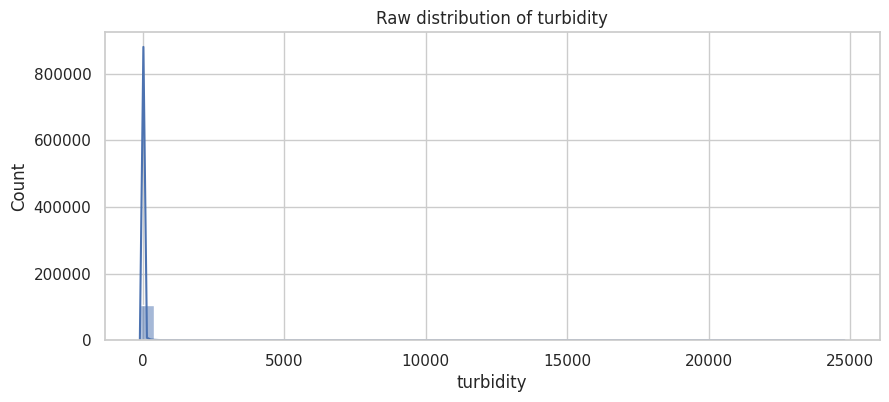

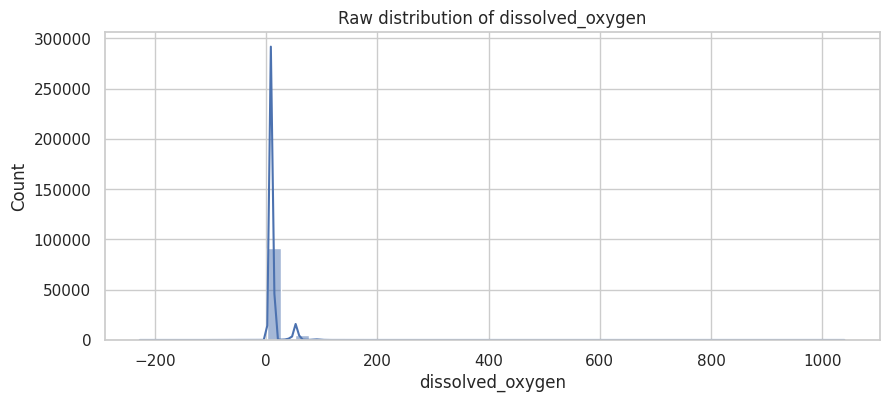

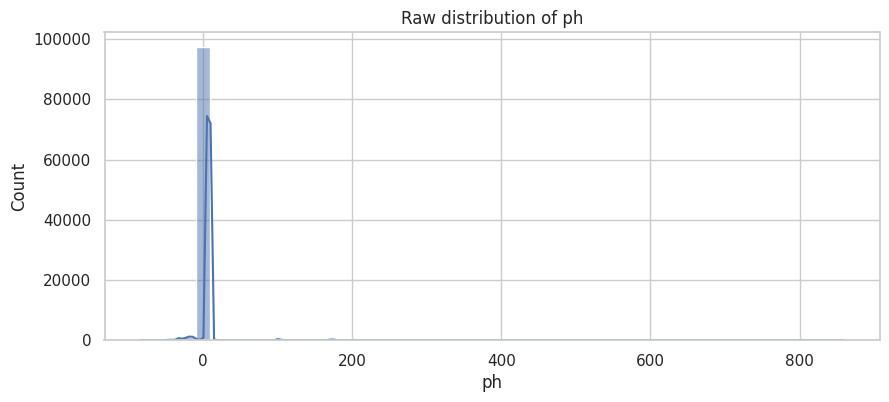

Raw ph vs turbidity correlation: 0.0839


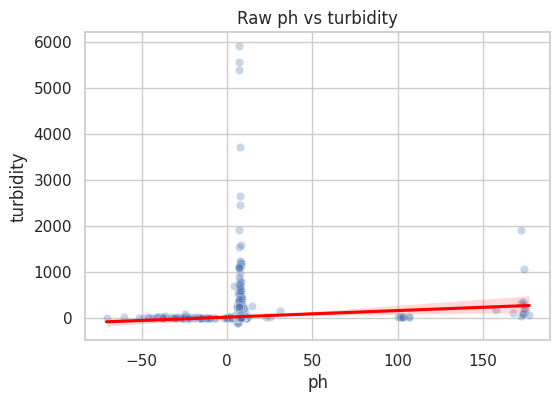

Raw dissolved_oxygen vs turbidity correlation: -0.0096


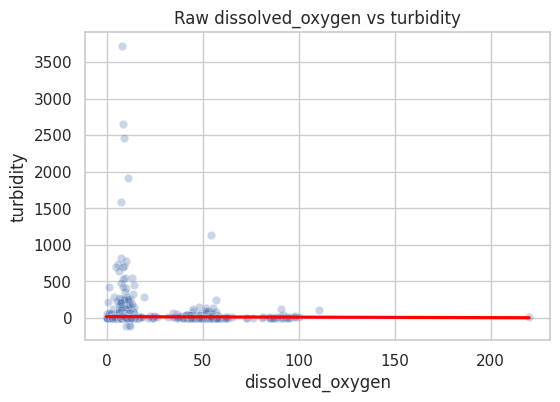

Raw ph vs dissolved_oxygen correlation: 0.0236


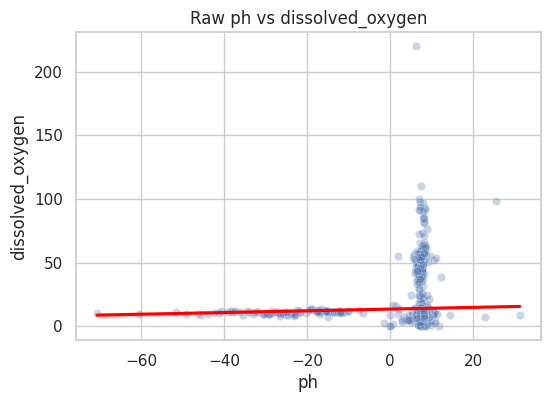

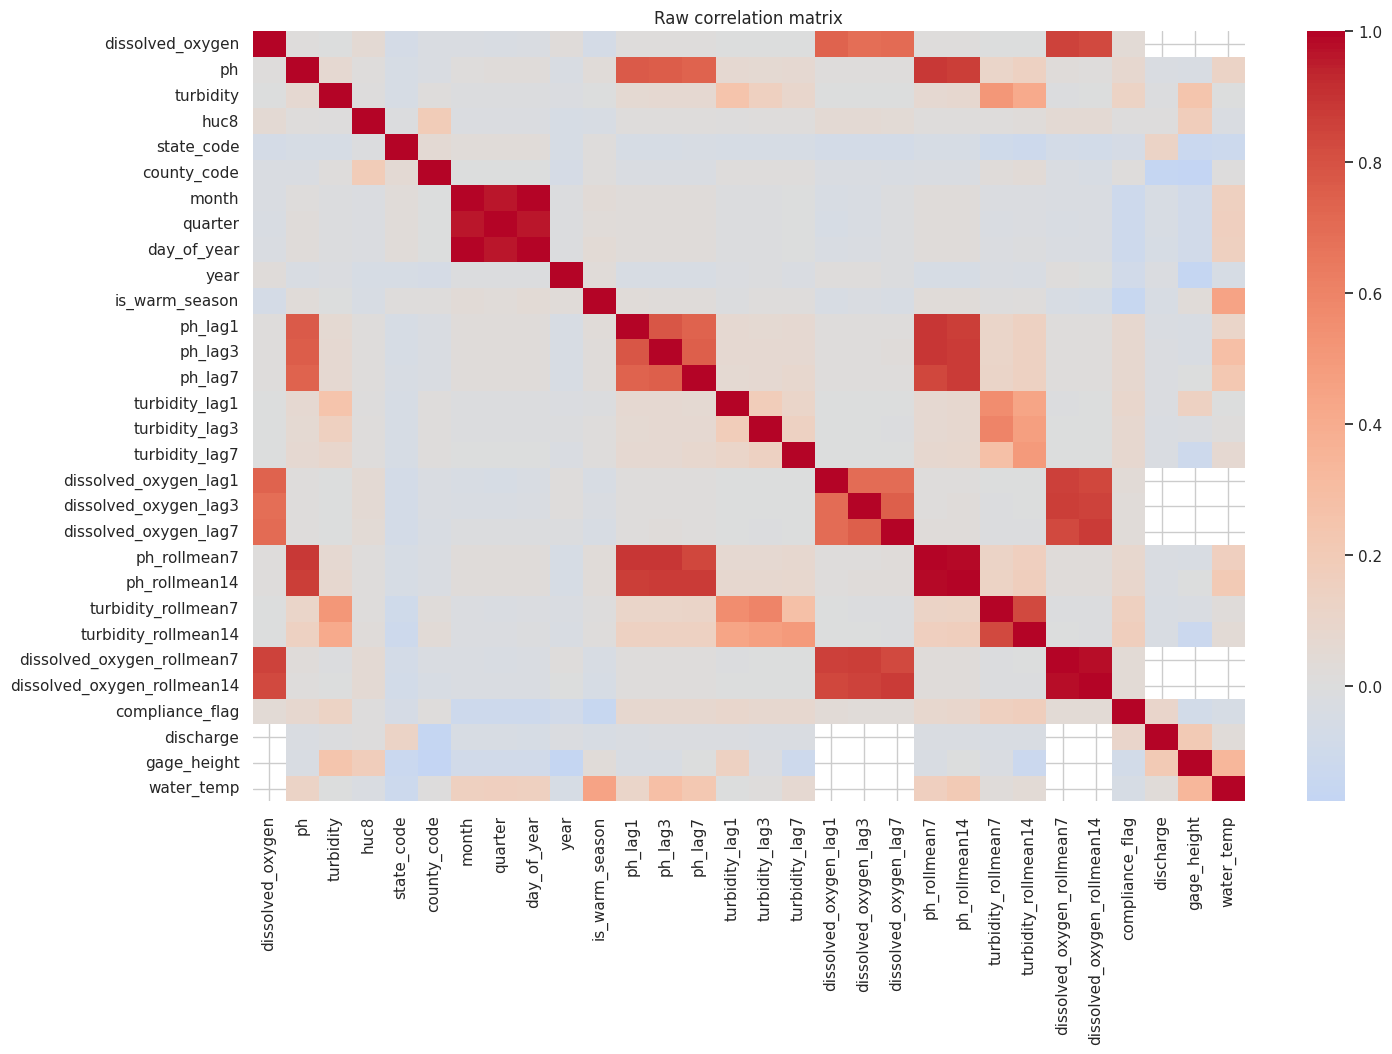

In [ ]:
# Calculates the percentage of missing values in each column, sorts them from highest to lowest, and displays the top 50 columns with the most missing data.

print("Missing % by column")
display((df.isna().mean() * 100).sort_values(ascending=False).head(50))

# Select the main water-quality variables and produces summary statistics such as count, mean, standard deviation, minimum, quartiles, and maximum.
core_cols = [c for c in ["turbidity", "dissolved_oxygen", "ph"] if c in df.columns]
display(df[core_cols].describe().T)

for col in core_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col].dropna(), kde=True, bins=50)
    plt.title(f"Raw distribution of {col}")
    plt.show()

# Plot the raw distribution of each key variable. This helps identify skewness, extreme values, unusual ranges, and whether variables may require transformation or outlier treatment
# scatterplot to compare key variable pairs such as pH versus turbidity and dissolved oxygen versus turbidity. Pint their raw correlations and adds a regression line to visually assess linear relationships.
sample = df.sample(min(len(df), 10000), random_state=42)
for x, y in [("ph", "turbidity"), ("dissolved_oxygen", "turbidity"), ("ph", "dissolved_oxygen")]:
    if x in df.columns and y in df.columns:
        temp = sample[[x, y]].dropna()
        print(f"Raw {x} vs {y} correlation:", round(temp[x].corr(temp[y]), 4))
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=temp, x=x, y=y, alpha=0.3)
        sns.regplot(data=temp, x=x, y=y, scatter=False, color="red")
        plt.title(f"Raw {x} vs {y}")
        plt.show()

num_df_raw = df.select_dtypes(include=[np.number]).dropna(axis=1, how="all")
plt.figure(figsize=(16,10))
sns.heatmap(num_df_raw.corr(), cmap="coolwarm", center=0)
plt.title("Raw correlation matrix")
plt.show()


#### NOTE: 

Before preprocessing, exploratory data analysis (EDA) revealed substantial missingness and extreme variability across several variables. Hydrologic variables such as gage height (99.49% missing), water temperature (96.50%), and discharge (95.54%) exhibited the highest missing rates due to limited overlap between WQP and USGS monitoring coverage. Missingness also increased significantly after temporal feature engineering, with 7-day lag and 14-day rolling features showing missing rates between approximately 33% and 40%, reflecting the sequential nature of time-series calculations.

Descriptive statistics further showed that turbidity exhibited the greatest variability and strongest right-skewness (mean = 21.31 NTU; max = 24,800 NTU), indicating the presence of extreme event-driven observations. Dissolved oxygen and pH also contained implausible negative and extreme values, suggesting potential sensor, reporting, or measurement anomalies. These findings justified subsequent preprocessing steps including invalid-value filtering, outlier handling, selective imputation, and the use of separate dataset tracks for hydrologically enriched analyses (see Table 5).

Looking at the correlation matrix, we can see that the strongest correlations occur between each target variable and its own lagged and rolling features, confirming strong temporal dependence in the dataset. pH and dissolved oxygen exhibit more stable temporal structure than turbidity, while hydrologic variables show weaker raw linear relationships, suggesting that their influence may be nonlinear or site-specific.

## 4. Data Preprocessing



In [6]:
df_p = df.copy()

# ---- state code mapping ----
state_code_map = {
    4: "AZ",
    6: "CA",
    32: "NV",
    41: "OR",
    53: "WA"
}

if "state_abbr" not in df_p.columns and "state_code" in df_p.columns:
    df_p["state_abbr"] = df_p["state_code"].astype(int).map(state_code_map)

# ---- invalid value cleanup ----
if "ph" in df_p.columns:
    df_p.loc[(df_p["ph"] < 0) | (df_p["ph"] > 14), "ph"] = np.nan

if "dissolved_oxygen" in df_p.columns:
    df_p.loc[df_p["dissolved_oxygen"] < 0, "dissolved_oxygen"] = np.nan

if "turbidity" in df_p.columns:
    df_p.loc[df_p["turbidity"] < 0, "turbidity"] = np.nan

# ---- time features ----
df_p["month"] = df_p["date"].dt.month
df_p["quarter"] = df_p["date"].dt.quarter
df_p["day_of_year"] = df_p["date"].dt.dayofyear
df_p["year"] = df_p["date"].dt.year

if "is_warm_season" not in df_p.columns:
    df_p["is_warm_season"] = df_p["month"].isin([5,6,7,8,9]).astype(int)

SITE_COL = "site_id"
SITE_BG_COL = "usgs_site_no" if "usgs_site_no" in df_p.columns else SITE_COL

# ---- optional hydrologic imputation ----
hydro_cols = [c for c in ["gage_height", "discharge", "water_temp"] if c in df_p.columns]
if IMPUTE_HYDROLOGY and len(hydro_cols) > 0:
    for col in hydro_cols:
        site_month_mean = df_p.groupby([SITE_COL, "month"])[col].transform("mean")
        df_p[col] = df_p[col].fillna(site_month_mean)

        site_mean = df_p.groupby(SITE_COL)[col].transform("mean")
        df_p[col] = df_p[col].fillna(site_mean)

        global_mean = df_p[col].mean()
        df_p[col] = df_p[col].fillna(global_mean)

# ---- state-aware screening compliance flag ----
if STATE_AWARE_FLAG and "turbidity" in df_p.columns and "state_abbr" in df_p.columns:
    df_p["background_turbidity_est"] = (
        df_p.groupby(SITE_BG_COL)["turbidity"]
        .transform(lambda s: s.shift(1).rolling(window=30, min_periods=5).median())
    )

    site_bg = df_p.groupby(SITE_BG_COL)["turbidity"].transform("median")
    df_p["background_turbidity_est"] = df_p["background_turbidity_est"].fillna(site_bg)
    df_p["background_turbidity_est"] = df_p["background_turbidity_est"].fillna(df_p["turbidity"].median())

    df_p["compliance_flag_stateaware"] = pd.Series(np.nan, index=df_p.index, dtype="float")
    df_p["compliance_rule_used"] = None

    mask_or = df_p["state_abbr"] == "OR"
    if mask_or.any():
        turb = df_p.loc[mask_or, "turbidity"]
        bg = df_p.loc[mask_or, "background_turbidity_est"]
        df_p.loc[mask_or, "compliance_flag_stateaware"] = (turb > bg * 1.10).astype(int)
        df_p.loc[mask_or, "compliance_rule_used"] = "OR screening: >10% above background"

    mask_wa = df_p["state_abbr"] == "WA"
    if mask_wa.any():
        turb = df_p.loc[mask_wa, "turbidity"]
        bg = df_p.loc[mask_wa, "background_turbidity_est"]
        wa_flag = (
            ((bg <= 50) & (turb > bg + 5)) |
            ((bg > 50) & (turb > bg * 1.10))
        ).astype(int)
        df_p.loc[mask_wa, "compliance_flag_stateaware"] = wa_flag
        df_p.loc[mask_wa, "compliance_rule_used"] = "WA screening: +5 NTU over bg if <=50 else +10%"

    mask_ca = df_p["state_abbr"] == "CA"
    if mask_ca.any():
        turb = df_p.loc[mask_ca, "turbidity"]
        bg = df_p.loc[mask_ca, "background_turbidity_est"]
        df_p.loc[mask_ca, "compliance_flag_stateaware"] = (turb > bg * 1.20).astype(int)
        df_p.loc[mask_ca, "compliance_rule_used"] = "CA screening fallback: >20% above background"

    mask_az = df_p["state_abbr"] == "AZ"
    if mask_az.any():
        turb = df_p.loc[mask_az, "turbidity"]
        bg = df_p.loc[mask_az, "background_turbidity_est"]
        df_p.loc[mask_az, "compliance_flag_stateaware"] = (turb > bg * 1.20).astype(int)
        df_p.loc[mask_az, "compliance_rule_used"] = "AZ screening fallback: >20% above background"

    mask_nv = df_p["state_abbr"] == "NV"
    if mask_nv.any():
        turb = df_p.loc[mask_nv, "turbidity"]
        bg = df_p.loc[mask_nv, "background_turbidity_est"]
        df_p.loc[mask_nv, "compliance_flag_stateaware"] = (turb > bg * 1.20).astype(int)
        df_p.loc[mask_nv, "compliance_rule_used"] = "NV screening fallback: >20% above background"

    df_p["compliance_flag_stateaware"] = df_p["compliance_flag_stateaware"].astype("Int64")

# ---- optional outlier handling ----
outlier_cols = [c for c in [
    "turbidity", "dissolved_oxygen", "ph",
    "gage_height", "discharge", "water_temp"
] if c in df_p.columns]

if OUTLIER_MODE == "cap":
    for col in outlier_cols:
        s = df_p[col].dropna()
        if len(s) > 0:
            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            df_p[col] = df_p[col].clip(lower=lower, upper=upper)

elif OUTLIER_MODE == "remove":
    for col in outlier_cols:
        s = df_p[col].dropna()
        if len(s) > 0:
            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            df_p = df_p[
                df_p[col].isna() |
                ((df_p[col] >= lower) & (df_p[col] <= upper))
            ].copy()

# ---- final strict sort before any splitting ----
sort_cols = [c for c in ["state_abbr", SITE_COL, "date"] if c in df_p.columns]
df_p = df_p.sort_values(sort_cols).reset_index(drop=True)

print("Processed shape:", df_p.shape)
print("Sort columns used:", sort_cols)

if "compliance_flag_stateaware" in df_p.columns:
    print("\nState-aware flag counts")
    print(df_p["compliance_flag_stateaware"].value_counts(dropna=False))

display(df_p.head())


Processed shape: (144849, 42)
Sort columns used: ['state_abbr', 'site_id', 'date']

State-aware flag counts
compliance_flag_stateaware
0    103026
1     41823
Name: count, dtype: Int64


,site_id,date,dissolved_oxygen,ph,turbidity,site_name,site_type_name,huc8,state_code,county_code,organization_name,month,quarter,day_of_year,year,is_warm_season,ph_lag1,ph_lag3,ph_lag7,turbidity_lag1,turbidity_lag3,turbidity_lag7,dissolved_oxygen_lag1,dissolved_oxygen_lag3,dissolved_oxygen_lag7,ph_rollmean7,ph_rollmean14,turbidity_rollmean7,turbidity_rollmean14,dissolved_oxygen_rollmean7,dissolved_oxygen_rollmean14,compliance_flag,usgs_site_no_x,usgs_site_no_y,discharge,gage_height,water_temp,usgs_site_no,state_abbr,background_turbidity_est,compliance_flag_stateaware,compliance_rule_used
0,AK-CHIN_WQX-LTP-20,2015-03-30,8.57,8.72,11.20,Ak-Chin Termination Pond,Canal Drainage,15050303.0,4,21.0,Ak-Chin Indian Community (Tribal),3,1,89,2015,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,None,None,5600.210001,4.125857,11.739948,None,AZ,3.4,1,AZ screening fallback: >20% above background
1,AK-CHIN_WQX-LTP-20,2015-09-23,6.91,8.28,6.41,Ak-Chin Termination Pond,Canal Drainage,15050303.0,4,21.0,Ak-Chin Indian Community (Tribal),9,3,266,2015,1,8.72,NaN,NaN,11.20,NaN,NaN,8.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,None,None,5600.210001,4.125857,11.739948,None,AZ,3.4,1,AZ screening fallback: >20% above background
2,AK-CHIN_WQX-LTP-20,2015-12-05,8.10,8.33,8.23,Ak-Chin Termination Pond,Canal Drainage,15050303.0,4,21.0,Ak-Chin Indian Community (Tribal),12,4,339,2015,0,8.28,NaN,NaN,6.41,NaN,NaN,6.91,NaN,NaN,8.443333,NaN,8.613333,NaN,7.860,NaN,1,None,None,5600.210001,4.125857,11.739948,None,AZ,3.4,1,AZ screening fallback: >20% above background
3,AK-CHIN_WQX-LTP-20,2016-02-29,10.26,8.07,4.11,Ak-Chin Termination Pond,Canal Drainage,15050303.0,4,21.0,Ak-Chin Indian Community (Tribal),2,1,60,2016,0,8.33,8.72,NaN,8.23,11.20,NaN,8.10,8.57,NaN,8.350000,NaN,7.487500,NaN,8.460,NaN,0,None,None,5600.210001,4.125857,11.739948,None,AZ,3.4,1,AZ screening fallback: >20% above background
4,AK-CHIN_WQX-LTP-20,2016-04-27,6.85,8.98,6.70,Ak-Chin Termination Pond,Canal Drainage,15050303.0,4,21.0,Ak-Chin Indian Community (Tribal),4,2,118,2016,1,8.07,8.28,NaN,4.11,6.41,NaN,10.26,6.91,NaN,8.476000,NaN,7.330000,NaN,8.138,NaN,1,None,None,5600.210001,4.125857,11.739948,None,AZ,3.4,1,AZ screening fallback: >20% above background


| Issue | Variables Affected | Detection Method | Treatment Applied | Rationale |
|---|---|---|---|---|
| Missing values from temporal feature engineering | Lag features, rolling means | Null-count and percentage audit after feature creation | Retained initially; rows excluded selectively depending on modeling task | Lag and rolling features inherently require prior observations and therefore create structural missingness in time-series data |
| Missing hydrologic data | Discharge, gage height, water temperature | Null-count analysis after WQP–USGS merge | Optional site-month mean imputation; incomplete rows retained in Dataset A | Not all WQP stations had corresponding USGS enrichment data |
| Missing target observations | Turbidity, pH, dissolved oxygen | Missing-value audit | Rows excluded for target-specific supervised modeling | Predictive models require valid target labels |
| Invalid pH values | pH | Range validation (outside 0–14) | Invalid observations removed or converted to missing | Values outside the chemically valid range are physically implausible |
| Outliers | Turbidity, dissolved oxygen, pH | IQR-based outlier screening | Outliers retained by default; optional capping applied during sensitivity testing | Environmental spikes may represent genuine contamination or storm-driven events |
| Extreme hydrologic values | Discharge, gage height, water temperature | Quantile/IQR audit | Optional capping/winsorization | Reduces instability caused by extreme hydrologic measurements |
| Duplicate site-day records | All variables | Duplicate detection using site/date combinations | Aggregated using daily mean values | Ensures one observation per site-day for temporal modeling |
| Inconsistent parameter naming | Water-quality parameters | Parameter mapping audit | Standardized into canonical variable names | Required for consistent merging and feature engineering |
| Temporal inconsistencies | Date/time variables | Datetime parsing and ordering checks | Standardized datetime formats and chronological sorting | Necessary for lag, rolling-window, and sequence models |
| Leakage risk in compliance modeling | Compliance flags and contemporaneous targets | Feature-selection review | Current-row compliance variables excluded from predictors | Reduces target leakage in RQ4 classification models |

## 5. EDA after preprocessing (after data prep-processing to address the issues mentioned ealier)

Missing % after preprocessing


,0
usgs_site_no_y,94.803554
usgs_site_no_x,94.733136
usgs_site_no,91.359278
ph_lag7,40.110736
dissolved_oxygen_lag7,38.886703
ph_rollmean14,38.689256
dissolved_oxygen_rollmean14,37.261562
ph_lag3,35.069624
turbidity_lag7,34.948809
dissolved_oxygen_lag3,34.441384


,count,mean,std,min,25%,50%,75%,max
turbidity,101514.0,6.418480,6.807044,0.000000,1.350000,3.40,9.10,20.725000
dissolved_oxygen,99639.0,10.040648,2.591305,4.118726,8.487491,9.96,11.40,15.768764
ph,97745.0,7.523167,0.596853,5.865000,7.110000,7.50,7.94,9.185000


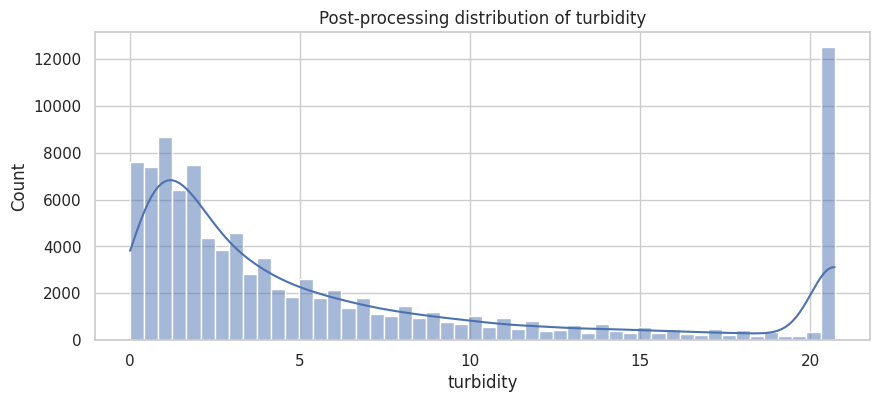

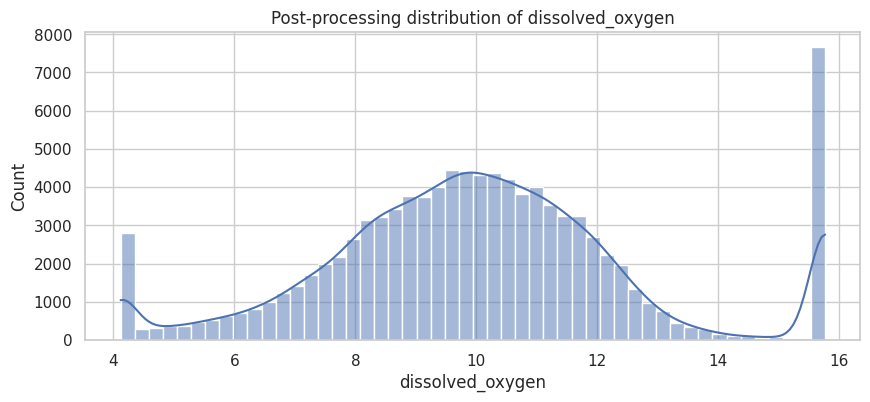

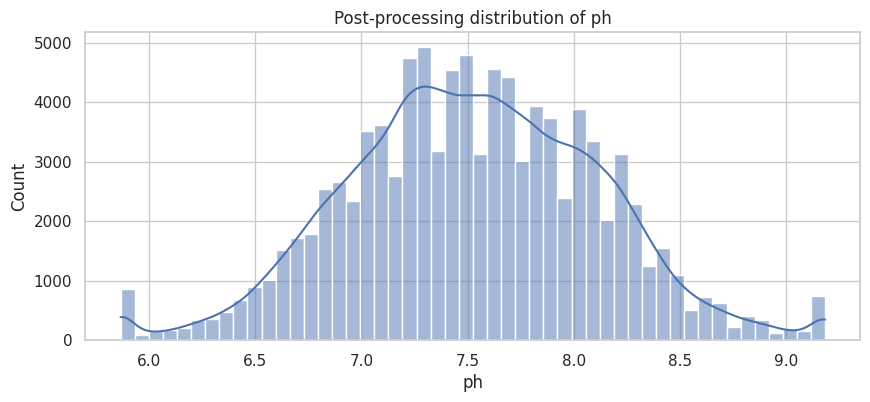

Post ph vs turbidity correlation: -0.0437


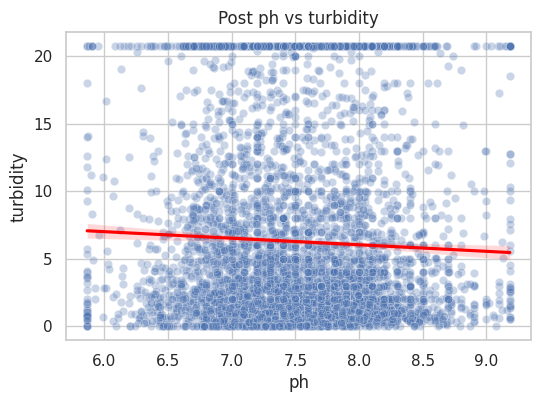

Post dissolved_oxygen vs turbidity correlation: 0.0138


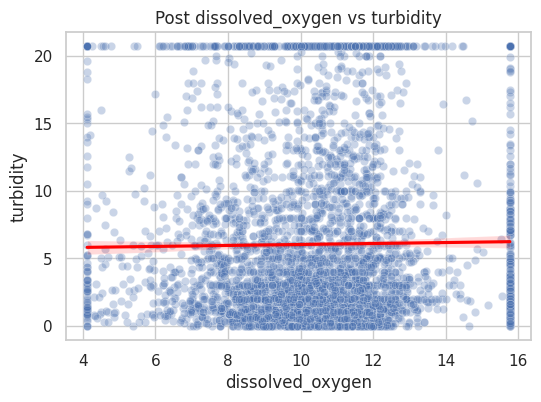

Post ph vs dissolved_oxygen correlation: -0.0474


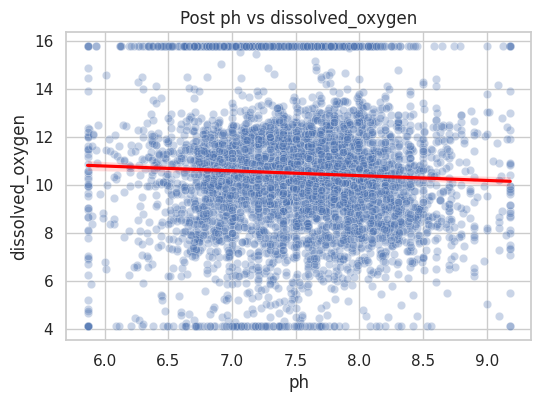

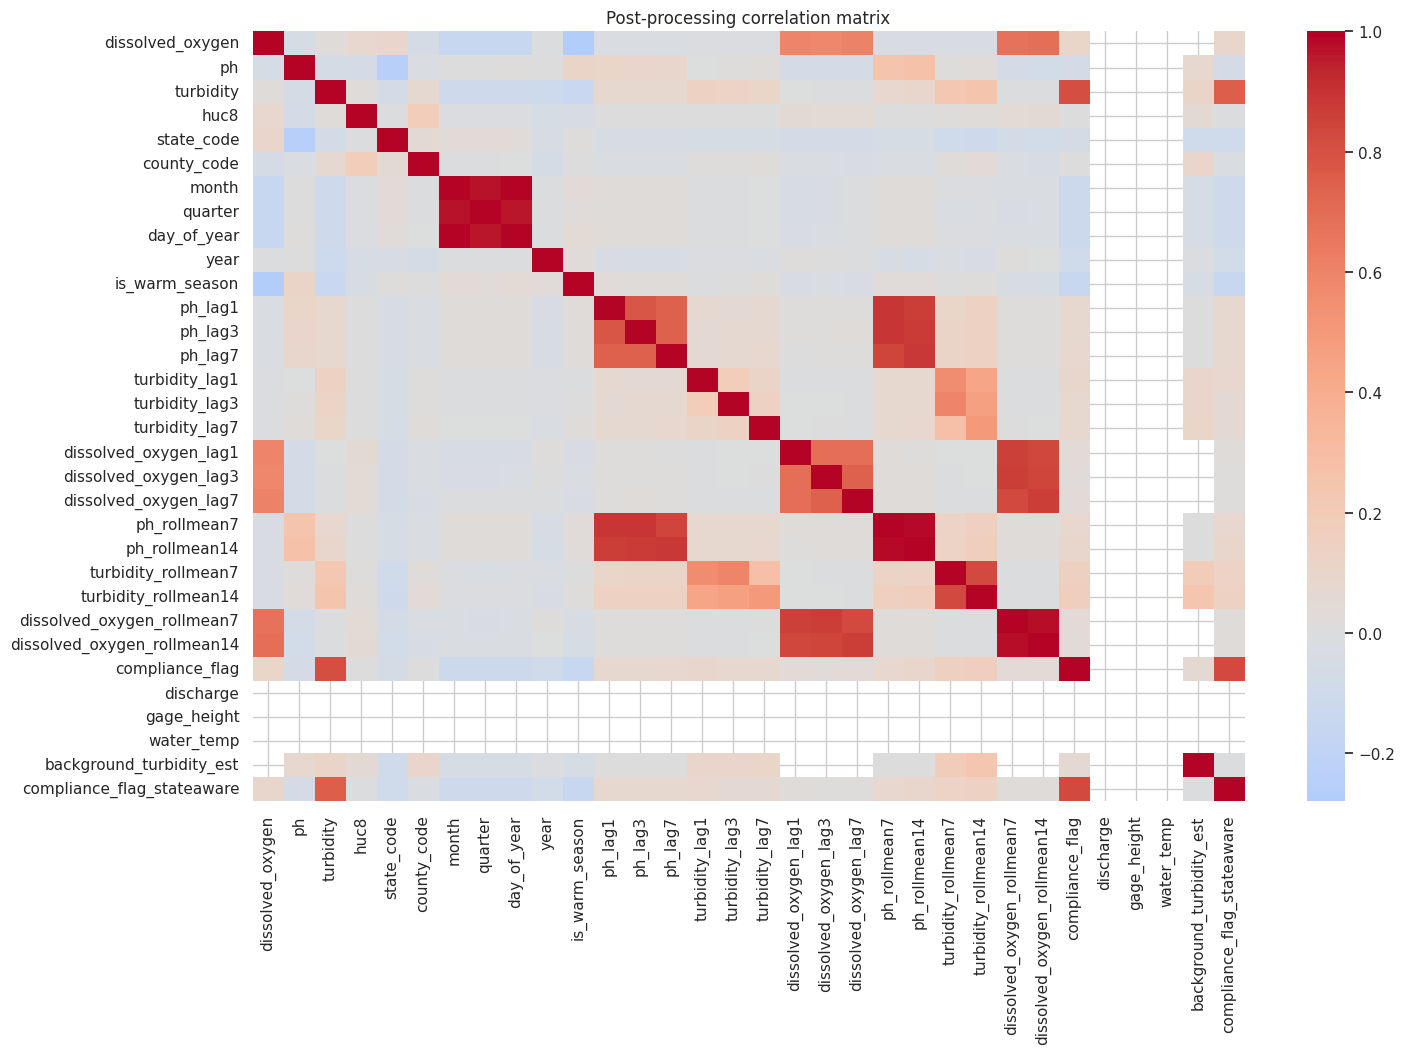

In [ ]:
# exploratory data analysis after preprocessing.
print("Missing % after preprocessing")
display((df_p.isna().mean() * 100).sort_values(ascending=False).head(50))

# percentage of missing values after preprocessing and helps confirm whether imputation, filtering, or cleaning steps worked.
post_core_cols = [c for c in ["turbidity", "dissolved_oxygen", "ph"] if c in df_p.columns]
display(df_p[post_core_cols].describe().T)

# summarize the cleaned versions of the key target variables: turbidity, dissolved oxygen, and pH.

for col in post_core_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(df_p[col].dropna(), kde=True, bins=50)
    plt.title(f"Post-processing distribution of {col}")
    plt.show()

# post-processing distributions. This helps compare whether outlier capping, invalid-value removal, or imputation changed the shape of the data.

# the scatterplot post-processing correlations between major water-quality variables and visualizes their relationships with regression lines.

# the heatmap for post-processing correlation matrix for numeric variables. This helps identify whether preprocessing changed variable relationships, reduced noise, or introduced stronger correlations useful for modeling.

sample_post = df_p.sample(min(len(df_p), 10000), random_state=42)
for x, y in [("ph", "turbidity"), ("dissolved_oxygen", "turbidity"), ("ph", "dissolved_oxygen")]:
    if x in df_p.columns and y in df_p.columns:
        temp = sample_post[[x, y]].dropna()
        print(f"Post {x} vs {y} correlation:", round(temp[x].corr(temp[y]), 4))
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=temp, x=x, y=y, alpha=0.3)
        sns.regplot(data=temp, x=x, y=y, scatter=False, color="red")
        plt.title(f"Post {x} vs {y}")
        plt.show()

num_df_post = df_p.select_dtypes(include=[np.number]).dropna(axis=1, how="all")
plt.figure(figsize=(16,10))
sns.heatmap(num_df_post.corr(), cmap="coolwarm", center=0)
plt.title("Post-processing correlation matrix")
plt.show()


#### NOTE:- 

Summary statistics revealed clear differences among the target variables. Turbidity had the largest spread and the strongest right tail, with a mean of 6.42 NTU, a median of 3.40 NTU, and a maximum above 20 NTU. Dissolved oxygen had a mean near 10.04 mg/L and a substantially tighter distribution (see Figure 2). pH was the most stable variable, with a mean of 7.52 and relatively low variance. These descriptive patterns immediately suggested that turbidity would be the most difficult forecasting problem and that model families robust to skewness and nonlinear spikes might perform best.


Turbidity remains strongly right-skewed with a capped upper-end spike, indicating persistent event-driven variability even after preprocessing. Dissolved oxygen shows a smoother, near-bell-shaped distribution with bounded extremes, while pH is the most symmetric and stable target. These distributional differences help explain why turbidity is harder to forecast and why model performance varies across targets.

Looking at the correlation matrix, we see that the strongest correlations occur between each target variable and its own lagged and rolling features, confirming strong temporal dependence in the dataset. pH and dissolved oxygen exhibit more stable temporal structure than turbidity, while hydrologic variables show weaker raw linear relationships, suggesting that their influence may be nonlinear or site-specific.

## 6. Create Track A and Track B

#### Track A vs Track B 

A dual-track dataset strategy was adopted to balance sample-size preservation with hydrologic feature completeness. Track A prioritized temporal continuity and observation volume for forecasting and anomaly-detection tasks, whereas Track B prioritized enriched environmental feature completeness for driver analysis and compliance-risk modeling

Dataset Track

Track A
Maximize sample size for forecasting/anomaly tasks
Use the largest clean dataset possible even if some hydrologic variables are missing

Track B
Enable hydrologic driver analysis and compliance modeling
Use a smaller but feature-complete dataset with enriched environmental variables

After merging EPA and USGS data:
* WQP water-quality data with
* USGS hydrologic/environmental data

We discovered that:
* Many stations had water-quality measurements
* But not all stations had:
    * discharge
    * gage height
    * water temperature
    * streamflow enrichment


Track A Dataset was designed to support the following:
* RQ1 → Forecasting
* RQ3 → Anomaly detection
* RQ5 → Model comparison

These tasks primarily require:
* temporal continuity
* sufficient observations
* strong signal in historical water-quality values
rather than complete hydrologic enrichment.

Track A (statistical power + temporal coverage) works for Forecasting becasue forecasting models like Linear Regression, Random Forest, XGBoost, LSTM can still learn strong predictive relationships using lagged turbidity, rolling averages, seasonality, time features and historical trends even when discharge/gage data are partially missing.


Track B was designed for:
* RQ2 → Driver analysis
* RQ4 → Compliance classification
These questions explicitly require environmental/hydrologic variables.  We cannot perform heavy imputation for missing hydrologic values as that would introduce scientific risks. Hence Track B uses optional controlled imputation but avoids over-reliance on synthetic values.


In [8]:
df_A = df_p.copy()
df_B = df_p.copy()

print("Track A shape:", df_A.shape)
print("Track B shape:", df_B.shape)


Track A shape: (144849, 42)
Track B shape: (144849, 42)


## 7. Common feature lists

In [ ]:
# create separate feature lists for Track A forecasting and Track B driver analysis.
# 

numeric_A = df_A.select_dtypes(include=[np.number]).columns.tolist()
numeric_B = df_B.select_dtypes(include=[np.number]).columns.tolist()

forecast_base_features_A = [c for c in numeric_A if c not in ["compliance_flag", "compliance_flag_stateaware"]]

driver_features_B = [
    c for c in numeric_B
    if (
        c in ["gage_height", "discharge", "water_temp", "month", "day_of_year", "year", "is_warm_season", "quarter"]
        or "lag" in c.lower()
        or "roll" in c.lower()
    )
]
driver_features_B = list(dict.fromkeys(driver_features_B))

print("Track A numeric features:", len(forecast_base_features_A))
print("Track B driver features:", driver_features_B[:50])


Track A numeric features: 30
Track B driver features: ['month', 'quarter', 'day_of_year', 'year', 'is_warm_season', 'ph_lag1', 'ph_lag3', 'ph_lag7', 'turbidity_lag1', 'turbidity_lag3', 'turbidity_lag7', 'dissolved_oxygen_lag1', 'dissolved_oxygen_lag3', 'dissolved_oxygen_lag7', 'ph_rollmean7', 'ph_rollmean14', 'turbidity_rollmean7', 'turbidity_rollmean14', 'dissolved_oxygen_rollmean7', 'dissolved_oxygen_rollmean14', 'compliance_flag', 'discharge', 'gage_height', 'water_temp', 'compliance_flag_stateaware']


## 8. RQ1 Forecasting baselines + CatBoost + LightGBM + Ensemble

Run the RQ1 forecasting experiment for three water-quality targets: turbidity, dissolved_oxygen, and ph.

In [ ]:
rq1_results = []
rq1_store = {}

# loop through each target variable
for target in ["turbidity", "dissolved_oxygen", "ph"]:
    print("\n" + "="*80)
    print("RQ1 target:", target)
# build a feature set using Track A numeric variables while excluding the active target and compliance flags to reduce leakage.

    feature_cols = [c for c in forecast_base_features_A if c not in ["turbidity", "dissolved_oxygen", "ph"]]
    feature_cols += [c for c in df_A.columns if ("lag" in c.lower() or "roll" in c.lower()) and c in numeric_A]
    feature_cols = list(dict.fromkeys([c for c in feature_cols if c in df_A.columns and c != target]))
# remove rows where the target is missing
    data = df_A.dropna(subset=[target]).copy()
    X = data[feature_cols].select_dtypes(include=[np.number]).copy()
    y = data[target].copy()

    X = X.dropna(axis=1, how="all")
    constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    if constant_cols:
        X = X.drop(columns=constant_cols)

# dataset split chronologically into 80% training data and 20% testing data:
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

#Missing predictor values imputed using the median, and features are scaled using MinMax scaling
    imp = SimpleImputer(strategy="median")
    scaler = MinMaxScaler()

    X_train_i = imp.fit_transform(X_train)
    X_test_i = imp.transform(X_test)
    X_train_s = scaler.fit_transform(X_train_i)
    X_test_s = scaler.transform(X_test_i)

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1, max_depth=12)
    }
    if XGB_AVAILABLE:
        models["XGBoost"] = XGBRegressor(
            n_estimators=250, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )
    if CATBOOST_AVAILABLE:
        models["CatBoost"] = CatBoostRegressor(
            iterations=500, learning_rate=0.05, depth=6,
            loss_function="RMSE", eval_metric="RMSE",
            random_seed=42, verbose=0
        )
    if LIGHTGBM_AVAILABLE:
        models["LightGBM"] = LGBMRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42
        )

    preds_by_model = {}

    for model_name, model in models.items():
        if model_name in ["Linear Regression", "Random Forest", "XGBoost"]:
            model.fit(X_train_s, y_train)
            preds = model.predict(X_test_s)
        else:
            model.fit(X_train_i, y_train)
            preds = model.predict(X_test_i)

        preds_by_model[model_name] = preds

        rq1_results.append({
            "RQ": "RQ1", "target": target, "model": model_name,
            "RMSE": mean_squared_error(y_test, preds) ** 0.5,
            "MAE": mean_absolute_error(y_test, preds),
            "R2": r2_score(y_test, preds)
        })

    ensemble_members = [m for m in ["XGBoost", "CatBoost", "LightGBM", "Random Forest"] if m in preds_by_model]
    if len(ensemble_members) >= 2:
        weights = {}
        for m in ensemble_members:
            if m == "Random Forest":
                weights[m] = 0.15
            elif m == "LightGBM":
                weights[m] = 0.25
            elif m == "XGBoost":
                weights[m] = 0.30
            elif m == "CatBoost":
                weights[m] = 0.30

        weight_sum = sum(weights.values())
        ensemble_pred = sum(preds_by_model[m] * weights[m] for m in ensemble_members) / weight_sum

        rq1_results.append({
            "RQ": "RQ1", "target": target, "model": "Weighted Ensemble",
            "RMSE": mean_squared_error(y_test, ensemble_pred) ** 0.5,
            "MAE": mean_absolute_error(y_test, ensemble_pred),
            "R2": r2_score(y_test, ensemble_pred)
        })

    rq1_store[target] = {"X_train_i": X_train_i, "X_test_i": X_test_i, "X_train_s": X_train_s, "X_test_s": X_test_s, "y_train": y_train, "y_test": y_test}

rq1_results_df = pd.DataFrame(rq1_results).sort_values(["target", "RMSE"])
display(rq1_results_df)



RQ1 target: turbidity
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4591
[LightGBM] [Info] Number of data points in the train set: 81211, number of used features: 26
[LightGBM] [Info] Start training from score 6.678854
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

,RQ,target,model,RMSE,MAE,R2
6,RQ1,dissolved_oxygen,Random Forest,1.197613,0.780173,0.683100
9,RQ1,dissolved_oxygen,Weighted Ensemble,1.199904,0.798816,0.681886
8,RQ1,dissolved_oxygen,LightGBM,1.210216,0.805115,0.676395
7,RQ1,dissolved_oxygen,XGBoost,1.249613,0.841675,0.654983
5,RQ1,dissolved_oxygen,Linear Regression,1.781633,1.349726,0.298665
14,RQ1,ph,Weighted Ensemble,0.327306,0.234638,0.620688
13,RQ1,ph,LightGBM,0.327422,0.235292,0.620421
12,RQ1,ph,XGBoost,0.330840,0.236812,0.612453
11,RQ1,ph,Random Forest,0.333415,0.239987,0.606398
10,RQ1,ph,Linear Regression,0.526399,0.418098,0.018890


## 9. LSTM forecasting track

Let us run the LSTM deep learning model for RQ1 forecasting to answer can an LSTM model learn temporal patterns from the previous 14 observations and use them to forecast future water-quality values. 

Test whether a sequence-based neural network can predict future turbidity, dissolved_oxygen, and ph using the previous 14 observations.


The LSTM architecture includes:

* First LSTM layer with 64 units
* Dropout layer to reduce overfitting
* Second LSTM layer with 32 units
* Another dropout layer
* Dense hidden layer
* Final output layer for regression

In [ ]:
rq1_lstm_results = []
# loop through each target variable
# For each target, select water-quality, seasonal, lag, and rolling-window features while excluding compliance flags to reduce leakage.
# sort data by site and date so the model sees observations in the correct temporal order. 

for target in ["turbidity", "dissolved_oxygen", "ph"]:
    feature_cols = [c for c in df_A.columns if (
        c in ["turbidity", "dissolved_oxygen", "ph", "month", "day_of_year", "is_warm_season", "quarter"]
        or "lag" in c.lower() or "roll" in c.lower()
    ) and c in numeric_A and c not in ["compliance_flag", "compliance_flag_stateaware"]]

    temp = df_A[[c for c in ["state_abbr", SITE_COL, "date"] + feature_cols if c in df_A.columns]].copy()
    temp = temp.sort_values([c for c in ["state_abbr", SITE_COL, "date"] if c in temp.columns]).reset_index(drop=True)

#  for each monitoring site create 14-step sequences so each prediction uses the previous 14 observations to predict the next target value.

    X_list, y_list = [], []
    seq_len = 14
    for site_id, g in temp.groupby(SITE_COL):
        g = g.sort_values("date").copy()
        g[feature_cols] = g[feature_cols].ffill().bfill() # missing feature values forward-filled and backward-filled within each site
        g = g.dropna(subset=feature_cols + [target])
        if len(g) <= seq_len:
            continue
        vals = g[feature_cols].values
        yvals = g[target].values
        for i in range(seq_len, len(g)):
            X_list.append(vals[i-seq_len:i]); y_list.append(yvals[i])

    X_seq = np.array(X_list); y_seq = np.array(y_list)
    if len(X_seq) == 0:
        continue
# split sequanec data chronologically into 80% training and 20% testing data.
    split_idx = int(len(X_seq) * 0.8)
    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
    n_features = X_train.shape[2]

#  features and target scaled using MinMaxScaler, important for neural networks because LSTM models train more effectively when values are on a similar scale
    scaler_X = MinMaxScaler(); scaler_y = MinMaxScaler()
    X_train_s = scaler_X.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
    X_test_s = scaler_X.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)); y_test_s = scaler_y.transform(y_test.reshape(-1, 1))

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_len, n_features)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True) #Early stopping is used to stop training when validation loss stops improving

    model.fit(X_train_s, y_train_s, validation_split=0.2, epochs=40, batch_size=64, callbacks=[es], verbose=0)

    preds = scaler_y.inverse_transform(model.predict(X_test_s, verbose=0)).ravel()
    y_true = scaler_y.inverse_transform(y_test_s).ravel()

    rq1_lstm_results.append({
        "RQ":"RQ1","target":target,"model":"LSTM",
        "RMSE": mean_squared_error(y_true, preds) ** 0.5,
        "MAE": mean_absolute_error(y_true, preds),
        "R2": r2_score(y_true, preds)
    })

rq1_lstm_results_df = pd.DataFrame(rq1_lstm_results)
display(rq1_lstm_results_df)


,RQ,target,model,RMSE,MAE,R2
0,RQ1,turbidity,LSTM,3.959278,2.427319,0.509637
1,RQ1,dissolved_oxygen,LSTM,1.163500,0.804707,0.837299
2,RQ1,ph,LSTM,0.327751,0.219038,0.673760


## 10. TCN forecasting track (optionally done as an experiment)

In [12]:
rq1_tcn_results = []

for target in ["turbidity", "dissolved_oxygen", "ph"]:
    feature_cols = [c for c in df_A.columns if (
        c in ["turbidity", "dissolved_oxygen", "ph", "month", "day_of_year", "is_warm_season", "quarter"]
        or "lag" in c.lower() or "roll" in c.lower()
    ) and c in numeric_A and c not in ["compliance_flag", "compliance_flag_stateaware"]]

    temp = df_A[[c for c in ["state_abbr", SITE_COL, "date"] + feature_cols if c in df_A.columns]].copy()
    temp = temp.sort_values([c for c in ["state_abbr", SITE_COL, "date"] if c in temp.columns]).reset_index(drop=True)

    X_list, y_list = [], []
    seq_len = 14
    for site_id, g in temp.groupby(SITE_COL):
        g = g.sort_values("date").copy()
        g[feature_cols] = g[feature_cols].ffill().bfill()
        g = g.dropna(subset=feature_cols + [target])
        if len(g) <= seq_len:
            continue
        vals = g[feature_cols].values
        yvals = g[target].values
        for i in range(seq_len, len(g)):
            X_list.append(vals[i-seq_len:i]); y_list.append(yvals[i])

    X_seq = np.array(X_list); y_seq = np.array(y_list)
    if len(X_seq) == 0:
        continue

    split_idx = int(len(X_seq) * 0.8)
    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]
    n_features = X_train.shape[2]

    scaler_X = MinMaxScaler(); scaler_y = MinMaxScaler()
    X_train_s = scaler_X.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
    X_test_s = scaler_X.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)); y_test_s = scaler_y.transform(y_test.reshape(-1, 1))

    model = tf.keras.Sequential([
        Conv1D(64, 3, padding="causal", activation="relu", input_shape=(seq_len, n_features)),
        Dropout(0.2),
        Conv1D(64, 3, dilation_rate=2, padding="causal", activation="relu"),
        Dropout(0.2),
        Conv1D(32, 3, dilation_rate=4, padding="causal", activation="relu"),
        GlobalAveragePooling1D(),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    model.fit(X_train_s, y_train_s, validation_split=0.2, epochs=40, batch_size=64, callbacks=[es], verbose=0)

    preds = scaler_y.inverse_transform(model.predict(X_test_s, verbose=0)).ravel()
    y_true = scaler_y.inverse_transform(y_test_s).ravel()

    rq1_tcn_results.append({
        "RQ":"RQ1","target":target,"model":"TCN",
        "RMSE": mean_squared_error(y_true, preds) ** 0.5,
        "MAE": mean_absolute_error(y_true, preds),
        "R2": r2_score(y_true, preds)
    })

rq1_tcn_results_df = pd.DataFrame(rq1_tcn_results)
display(rq1_tcn_results_df)


,RQ,target,model,RMSE,MAE,R2
0,RQ1,turbidity,TCN,4.029493,2.532806,0.492090
1,RQ1,dissolved_oxygen,TCN,1.078136,0.645033,0.860297
2,RQ1,ph,TCN,0.325647,0.215306,0.677934


## 11. RQ2 Driver analysis

Which hydrologic, seasonal, lagged, and rolling-window variables explain short-term changes in turbidity, dissolved oxygen, and pH?

Models: Linear Regression (baseline), Random Forest, XGBoost

Targets: Turbidity, pH, Dissolved Oxygen (DO). 

Predictors: Hydrologic, temporal, seasonal, and lagged variables in Dataset B, including discharge, gage height, water temperature, month, quarter, day of year, year, warm-season indicator, and engineered lag/rolling statistics.

Significance testing plus feature ranking / SHAP


OLS helps identify which predictors are statistically significant. The p-values show whether variables such as discharge, water temperature, seasonality, lag features, or rolling means have meaningful relationships with the target variable.

Random Forest and XGBoost capture nonlinear relationships that OLS may miss. Their feature importance outputs help identify which variables contribute most to prediction performance.

We will try to answer RQ2 by combining:

* OLS p-values for statistical significance
* Random Forest feature importance for nonlinear driver importance
* RMSE, MAE, and R² for predictive accuracy

The result will help is show not only which variables are associated with water-quality changes, but also which variables are most useful for forecasting those changes.

In [ ]:
rq2_results = []

#loop though each target variable

for target in ["turbidity", "dissolved_oxygen", "ph"]:
    data = df_B.dropna(subset=[target]).copy()
    #     select Track B driver features
    X = data[driver_features_B].copy().select_dtypes(include=[np.number]).dropna(axis=1, how="all")
    y = data[target].copy()

# remove empty or constant predictor columns
    constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    if constant_cols:
        X = X.drop(columns=constant_cols)

# split the data chronologically into 80% training and 20% testing
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# impute missing predictors using median imputation
# fit an OLS regression model to identify statistically significant predictors
    X_train_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    ols_model = sm.OLS(y_train, sm.add_constant(X_train_imp)).fit()

    print("\n", target, "significant OLS predictors")
    display(ols_model.pvalues[ols_model.pvalues < 0.05].sort_values().to_frame("p_value"))

    pre = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    X_train_i = pre.fit_transform(X_train)
    X_test_i = pre.transform(X_test)

# train a Random Forest model to estimate nonlinear feature importance
    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, max_depth=12)
    rf.fit(X_train_i, y_train)
    preds = rf.predict(X_test_i)

    rq2_results.append({
        "RQ":"RQ2","target":target,"model":"Random Forest",
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    })

    display(pd.DataFrame({"feature": X_train.columns, "importance": rf.feature_importances_}).sort_values("importance", ascending=False).head(15))

# optionally trains XGBoost if available
    if XGB_AVAILABLE:
        xgb = XGBRegressor(n_estimators=250, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42)
        xgb.fit(X_train_i, y_train)
        preds = xgb.predict(X_test_i)
        rq2_results.append({
            "RQ":"RQ2","target":target,"model":"XGBoost",
            "RMSE": mean_squared_error(y_test, preds) ** 0.5,
            "MAE": mean_absolute_error(y_test, preds),
            "R2": r2_score(y_test, preds)
        })

rq2_results_df = pd.DataFrame(rq2_results)
display(rq2_results_df)



 turbidity significant OLS predictors


,p_value
compliance_flag,0.000000e+00
compliance_flag_stateaware,0.000000e+00
turbidity_rollmean14,5.755839e-87
is_warm_season,3.008029e-58
const,4.018659e-54
year,1.186115e-52
turbidity_rollmean7,2.576571e-43
turbidity_lag3,9.370756e-06
quarter,1.554006e-03
dissolved_oxygen_rollmean14,2.014713e-03


,feature,importance
20,compliance_flag,0.749697
16,turbidity_rollmean7,0.129804
8,turbidity_lag1,0.033518
9,turbidity_lag3,0.024343
21,compliance_flag_stateaware,0.016107
10,turbidity_lag7,0.007404
2,day_of_year,0.006470
17,turbidity_rollmean14,0.004592
5,ph_lag1,0.002805
13,dissolved_oxygen_lag7,0.002621



 dissolved_oxygen significant OLS predictors


,p_value
is_warm_season,0.000000e+00
dissolved_oxygen_rollmean14,0.000000e+00
dissolved_oxygen_rollmean7,3.081349e-267
quarter,5.527660e-45
compliance_flag_stateaware,2.831275e-38
dissolved_oxygen_lag1,3.768131e-28
const,3.191228e-21
year,1.897690e-13
month,5.326741e-09
ph_rollmean14,1.456014e-07


,feature,importance
18,dissolved_oxygen_rollmean7,0.523262
11,dissolved_oxygen_lag1,0.375823
4,is_warm_season,0.026915
12,dissolved_oxygen_lag3,0.014423
2,day_of_year,0.013161
19,dissolved_oxygen_rollmean14,0.008746
13,dissolved_oxygen_lag7,0.005381
14,ph_rollmean7,0.004641
5,ph_lag1,0.003580
6,ph_lag3,0.003244



 ph significant OLS predictors


,p_value
ph_rollmean7,1.351715e-127
ph_rollmean14,5.302845e-115
is_warm_season,1.205946e-81
compliance_flag_stateaware,1.591724e-68
dissolved_oxygen_rollmean14,2.362028e-26
turbidity_rollmean14,2.586451e-16
dissolved_oxygen_rollmean7,5.663078e-09
day_of_year,3.432573e-08
ph_lag3,4.116169e-07
dissolved_oxygen_lag3,8.874185e-07


,feature,importance
14,ph_rollmean7,0.839540
5,ph_lag1,0.059956
6,ph_lag3,0.020347
7,ph_lag7,0.009084
2,day_of_year,0.009032
15,ph_rollmean14,0.008846
11,dissolved_oxygen_lag1,0.006818
13,dissolved_oxygen_lag7,0.005785
12,dissolved_oxygen_lag3,0.005146
19,dissolved_oxygen_rollmean14,0.004815


,RQ,target,model,RMSE,MAE,R2
0,RQ2,turbidity,Random Forest,2.333748,1.489445,0.875681
1,RQ2,turbidity,XGBoost,2.304513,1.482427,0.878776
2,RQ2,dissolved_oxygen,Random Forest,1.193646,0.775798,0.685196
3,RQ2,dissolved_oxygen,XGBoost,1.159952,0.757022,0.702718
4,RQ2,ph,Random Forest,0.338092,0.242087,0.595278
5,RQ2,ph,XGBoost,0.331262,0.235345,0.611465


Turbidity

The OLS analysis for turbidity showed that historical turbidity behavior was the strongest predictor of future turbidity levels. Rolling mean features (turbidity_rollmean14 and turbidity_rollmean7) were highly significant, indicating strong temporal persistence and autocorrelation in turbidity measurements. Compliance-related variables (compliance_flag and compliance_flag_stateaware) were also extremely significant, suggesting that elevated turbidity conditions are strongly associated with regulatory threshold exceedances. Seasonal and temporal variables such as is_warm_season, year, and quarter were significant, indicating that turbidity patterns vary over time and across seasons.

Random Forest feature importance results further confirmed the dominance of compliance indicators and historical turbidity features. The compliance_flag variable alone contributed nearly 75% of model importance, while lagged and rolling turbidity variables collectively represented the majority of the remaining predictive signal. This indicates that turbidity behavior is highly path-dependent and influenced strongly by prior contamination states.


----

Dissolved Oxygen

For dissolved oxygen (DO), the OLS results demonstrated that rolling averages and lagged DO measurements were the most statistically significant predictors. Both dissolved_oxygen_rollmean14 and dissolved_oxygen_rollmean7 exhibited extremely small p-values, confirming strong temporal continuity in dissolved oxygen dynamics. Seasonal variables such as is_warm_season, quarter, and month were also highly significant, suggesting that dissolved oxygen is strongly affected by environmental and climatic conditions.

The Random Forest feature importance analysis showed that dissolved_oxygen_rollmean7 and dissolved_oxygen_lag1 dominated model importance, together accounting for approximately 90% of predictive contribution. This indicates that recent dissolved oxygen conditions are highly informative for short-term forecasting. Secondary influences from pH and turbidity variables suggest interdependence among water-quality parameters.

----

pH

The pH OLS analysis indicated that pH rolling averages (ph_rollmean7 and ph_rollmean14) were the most significant predictors, demonstrating strong temporal stability and autocorrelation in pH behavior. Seasonal effects (is_warm_season) and compliance-related variables were also statistically significant, suggesting that pH variations are influenced by both environmental conditions and regulatory threshold states.

Feature importance analysis showed that ph_rollmean7 overwhelmingly dominated the Random Forest model, contributing approximately 84% of total importance. Lagged pH variables also contributed meaningfully, while dissolved oxygen and turbidity variables had smaller but still measurable influence. These findings suggest that pH dynamics are primarily self-driven but remain interconnected with broader water-quality conditions.

----

Comparative Model Performance

Across all three target variables, XGBoost consistently outperformed Random Forest, achieving lower RMSE and MAE values and slightly higher R² scores. Turbidity prediction achieved the strongest overall performance, with XGBoost obtaining an R² of approximately 0.879, indicating that the models captured most variability in turbidity behavior. Dissolved oxygen achieved moderate predictive performance (R² ≈ 0.703), while pH prediction was comparatively more difficult, with lower but still acceptable explanatory power (R² ≈ 0.611).

Overall, the results demonstrate that temporal rolling features, lagged variables, seasonality indicators, and compliance-related features are critical drivers of short-term water-quality prediction. The findings also confirm that ensemble ML approaches such as Random Forest and XGBoost are effective for modeling nonlinear environmental relationships in water-quality systems.

## 12. RQ2 TabNet (optional experiment)

In [15]:
!pip install pytorch-tabnet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.3 MB/s eta 0:00:00


In [22]:
%pip install pytorch-tabnet

In [23]:
if not TABNET_AVAILABLE:
    print("Install pytorch-tabnet first.")
else:
    rq2_tabnet_results = []

    for target in ["turbidity", "dissolved_oxygen", "ph"]:
        data = df_B.dropna(subset=[target]).copy()
        X = data[driver_features_B].copy().select_dtypes(include=[np.number]).dropna(axis=1, how="all")
        y = data[target].copy()

        constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
        if constant_cols:
            X = X.drop(columns=constant_cols)

        split_idx = int(len(X) * 0.8)
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

        imp = SimpleImputer(strategy="median"); scaler = MinMaxScaler()
        X_train_s = scaler.fit_transform(imp.fit_transform(X_train))
        X_test_s = scaler.transform(imp.transform(X_test))

        tabnet_model = TabNetRegressor(seed=42, verbose=0)
        tabnet_model.fit(
            X_train=X_train_s, y_train=y_train.values.reshape(-1,1),
            eval_set=[(X_test_s, y_test.values.reshape(-1,1))],
            max_epochs=100, patience=10, batch_size=1024, virtual_batch_size=128
        )

        preds = tabnet_model.predict(X_test_s).ravel()
        rq2_tabnet_results.append({
            "RQ":"RQ2","target":target,"model":"TabNet",
            "RMSE": mean_squared_error(y_test, preds) ** 0.5,
            "MAE": mean_absolute_error(y_test, preds),
            "R2": r2_score(y_test, preds)
        })

    rq2_tabnet_results_df = pd.DataFrame(rq2_tabnet_results)
    display(rq2_tabnet_results_df)


Install pytorch-tabnet first.


## 13. RQ3 Anomaly detection

Let us run the RQ3 anomaly detection experiment using Track A to test whether unsupervised methods can detect abnormal water-quality behavior better than a simple threshold baseline.

Modesl: Threshold baseline, Isolation Forest, Autoencoder

Target: Binary anomaly label derived from abnormal water-quality behavior. 

Predictors: Temporal, hydrologic, seasonal, and engineered water-quality features in Dataset A, including selected lagged and rolling variables, month, quarter, day of year, year, warm-season indicator, and available hydrologic predictors.

Rule-based, classical unsupervised, and deep unsupervised anomaly comparison


We will create an anomaly_label using rule-based abnormal conditions:
* Turbidity above the 98th percentile
* Dissolved oxygen below the 2nd percentile
* pH below 6.5 or above 8.5
These conditions are combined into one binary anomaly label - "anomaly_label"

The code compares three anomaly detection approaches:
- Threshold Baseline - Simple rule-based anomaly detection
- Isolation Forest - Tree-based unsupervised anomaly detection
- Autoencoder - Neural network reconstruction-error anomaly detection


Each model is evaluated using: Precision, Recall, F1-score, ROC-AUC

In [ ]:
# sort data by state, site, and date so observations remain in temporal order

df_A_rq3 = df_A.copy().sort_values([c for c in ["state_abbr", SITE_COL, "date"] if c in df_A.columns]).reset_index(drop=True)

# create an anomaly_label using rule-based abnormal conditions:
# Turbidity above the 98th percentile
# Dissolved oxygen below the 2nd percentile
# pH below 6.5 or above 8.5

parts = []
if "turbidity" in df_A_rq3.columns:
    parts.append(df_A_rq3["turbidity"] > df_A_rq3["turbidity"].quantile(0.98))
if "dissolved_oxygen" in df_A_rq3.columns:
    parts.append(df_A_rq3["dissolved_oxygen"] < df_A_rq3["dissolved_oxygen"].quantile(0.02))
if "ph" in df_A_rq3.columns:
    parts.append((df_A_rq3["ph"] < 6.5) | (df_A_rq3["ph"] > 8.5))

combined = parts[0]
for p in parts[1:]:
    combined = combined | p

df_A_rq3["anomaly_label"] = combined.astype(int)

rq3_feature_cols = [
    c for c in df_A_rq3.columns
    if (
        c in ["gage_height", "discharge", "water_temp", "month", "day_of_year", "year", "is_warm_season", "quarter"]
        or "lag" in c.lower() or "roll" in c.lower()
    )
]
rq3_feature_cols = [c for c in list(dict.fromkeys(rq3_feature_cols)) if c != "anomaly_label"]

X = df_A_rq3[rq3_feature_cols].select_dtypes(include=[np.number]).dropna(axis=1, how="all")
y = df_A_rq3["anomaly_label"].copy()

constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

# split data 80% for training and 20% testing
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# impute missing values using the median, and features are standardized using StandardScaler
imp = SimpleImputer(strategy="median"); scaler = StandardScaler()
X_train_s = scaler.fit_transform(imp.fit_transform(X_train))
X_test_s = scaler.transform(imp.transform(X_test))

if "turbidity" in X_test.columns:
    threshold_pred = (X_test["turbidity"].fillna(0) > X_test["turbidity"].quantile(0.95)).astype(int).values
else:
    threshold_pred = np.zeros(len(X_test), dtype=int)

iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(X_train_s)
iso_pred = np.where(iso.predict(X_test_s) == -1, 1, 0)

inp = Input(shape=(X_train_s.shape[1],))
x = Dense(64, activation="relu")(inp)
x = Dense(32, activation="relu")(x)
x = Dense(16, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(64, activation="relu")(x)
out = Dense(X_train_s.shape[1], activation="linear")(x)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer="adam", loss="mse")
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
autoencoder.fit(X_train_s, X_train_s, validation_split=0.2, epochs=40, batch_size=128, verbose=0, callbacks=[es])

recon = autoencoder.predict(X_test_s, verbose=0)
recon_error = np.mean((X_test_s - recon) ** 2, axis=1)
ae_pred = (recon_error > np.quantile(recon_error, 0.95)).astype(int)

rq3_rows = []
for model_name, pred in {"Threshold Baseline": threshold_pred, "Isolation Forest": iso_pred, "Autoencoder": ae_pred}.items():
    rq3_rows.append({
        "RQ":"RQ3","model":model_name,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, pred) if len(np.unique(y_test)) > 1 else np.nan
    })

rq3_results_df = pd.DataFrame(rq3_rows).sort_values("F1", ascending=False)
display(rq3_results_df)


,RQ,model,Precision,Recall,F1,ROC_AUC
2,RQ3,Autoencoder,0.089717,0.071982,0.079877,0.511713
1,RQ3,Isolation Forest,0.118182,0.007198,0.013570,0.501814
0,RQ3,Threshold Baseline,0.000000,0.000000,0.000000,0.500000


NOTE:- The anomaly detection results indicate that the Autoencoder model achieved the strongest overall performance among the evaluated approaches, although overall detection effectiveness remained limited. The Autoencoder obtained the highest F1-score (0.0799) and ROC-AUC (0.5117), suggesting a modest ability to distinguish anomalous water-quality events from normal observations. Its relatively balanced precision and recall indicate that reconstruction-error–based approaches were somewhat effective at identifying unusual temporal patterns in the dataset.

The Isolation Forest model achieved slightly higher precision (0.1182) but extremely low recall (0.0072), indicating that while detected anomalies were occasionally accurate, the model failed to identify the vast majority of actual anomalous events. This suggests that the Isolation Forest approach was overly conservative and struggled with the complex, noisy, and highly imbalanced environmental data distribution.

The Threshold Baseline model performed poorly across all evaluation metrics, with zero precision, recall, and F1-score, and an ROC-AUC of 0.50, equivalent to random classification. This demonstrates that simple rule-based threshold approaches were insufficient for capturing the nonlinear and context-dependent nature of water-quality anomalies.

Overall, the findings suggest that unsupervised deep learning methods such as Autoencoders offer greater potential for environmental anomaly detection compared to traditional statistical thresholds or tree-based isolation techniques. However, the low absolute performance metrics also indicate that anomaly detection in water-quality systems remains challenging due to class imbalance, limited labeled anomalies, and the stochastic nature of environmental events.

## 14. RQ4 Compliance classification using state-aware future flag
Let us run the RQ4 compliance-risk classification experiment to predict whether a site will have a next-period state-aware compliance-risk event.

Modesl: Logistic Regression (baseline), Random Forest, XGBoost
Target: compliance_flag_stateaware_next (future state-aware screening / surrogate compliance-risk flag). 

Predictors: Historical hydrologic, temporal, and engineered predictors, including discharge, gage height, water temperature, month, quarter, day of year, year, warm-season indicator, and lag/rolling features. Current-row compliance flags and contemporaneous target values are excluded to reduce leakage.

Operation risk classification with baseline and nonlinear challengers



In [ ]:
# check whether the required current compliance flag exists in Track B
# run the RQ4 modeling logic only if the required column exists

if "compliance_flag_stateaware" not in df_B.columns:
    print("compliance_flag_stateaware not found in dataset")
else:
    # copy Track B, sort by state, site, and date, and reset the index to ensures correct temporal ordering
    df_rq4 = df_B.copy().sort_values([c for c in ["state_abbr", SITE_COL, "date"] if c in df_B.columns]).reset_index(drop=True)
    
    
    # create the future target variable by shifting each site’s compliance flag one step forward
    df_rq4["compliance_flag_stateaware_next"] = df_rq4.groupby(SITE_COL)["compliance_flag_stateaware"].shift(-1)
    
    # remove the final record for each site because it has no next-period value
    df_rq4 = df_rq4.dropna(subset=["compliance_flag_stateaware_next"]).copy()
    # convert the future compliance-risk target into an integer binary label.
    df_rq4["compliance_flag_stateaware_next"] = df_rq4["compliance_flag_stateaware_next"].astype(int)

    # select candidate predictors - hydrologic variables, temporal variables, lag variables, and rolling-mean variables
    rq4_feature_cols = [
        c for c in df_rq4.columns
        if (
            c in ["gage_height", "discharge", "water_temp", "month", "day_of_year", "year", "is_warm_season", "quarter"]
            or "lag" in c.lower() or "roll" in c.lower()
        )
    ]
    # remove duplicate feature names while preserving order
    rq4_feature_cols = list(dict.fromkeys(rq4_feature_cols))

    # define variables that could leak the answer into the model, including current compliance flags, future compliance flags, and same-row water-quality target values
    leakage_cols = [
        "compliance_flag", "compliance_flag_next",
        "compliance_flag_stateaware", "compliance_flag_stateaware_next",
        "turbidity", "ph", "dissolved_oxygen"
    ]
    # remove leakage-risk variables from the feature set
    rq4_feature_cols = [c for c in rq4_feature_cols if c not in leakage_cols]

    # create the numeric predictor matrix and removes columns that are entirely missing

    X = df_rq4[rq4_feature_cols].select_dtypes(include=[np.number]).dropna(axis=1, how="all")
    # create the target variable for classification
    y = df_rq4["compliance_flag_stateaware_next"].copy()
    
    # identify predictor columns with no meaningful variation
    constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    
    # remove constant columns
    if constant_cols:
        X = X.drop(columns=constant_cols)

    # define an 80/20 chronological train-test split
    # create training and testing sets without random shuffling
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    # build a preprocessing pipeline that fills missing values using the median and scales features
    pre = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())])

    # fit preprocessing on training data only, then apply the same transformation to test data
    X_train_s = pre.fit_transform(X_train)
    X_test_s = pre.transform(X_test)

    # define baseline and ensemble classification models
    # create an interpretable baseline classifier and balances the classes
    # create a nonlinear tree-based classifier with balanced class weights
    # add XGBoost, CatBoost, LightGBM
    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, max_depth=10, class_weight="balanced")
    }
    if XGB_AVAILABLE:
        models["XGBoost"] = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric="logloss")
    if LIGHTGBM_AVAILABLE:
        models["LightGBM"] = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
    if CATBOOST_AVAILABLE:
        models["CatBoost"] = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, random_seed=42, verbose=0)
    
    # create an empty list to store model results
    # loop through each classification model
    # handle CatBoost separately because it can work directly with unscaled dataframe inputs
    rq4_rows = []
    for model_name, model in models.items():
        if model_name == "CatBoost":
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else pred # get predicted probabilities for ROC-AUC calculation
        else:
            model.fit(X_train_s, y_train) # fit all other models using the scaled training data
            pred = model.predict(X_test_s) # generate predicted classes for the test set
            prob = model.predict_proba(X_test_s)[:,1] if hasattr(model, "predict_proba") else pred  # get predicted probabilities for the positive compliance-risk class

        rq4_rows.append({
            "RQ":"RQ4","model":model_name,
            "Precision": precision_score(y_test, pred, zero_division=0), # measures how many predicted risk events were actually risk events
            "Recall": recall_score(y_test, pred, zero_division=0), # measures how many actual risk events the model successfully detected
            "F1": f1_score(y_test, pred, zero_division=0), # calculates the balance between precision and recall
            "ROC_AUC": roc_auc_score(y_test, prob) # measures how well the model separates risk and non-risk cases across thresholds
        })
    # get predicted probabilities for the positive compliance-risk class
    rq4_results_df = pd.DataFrame(rq4_rows).sort_values("F1", ascending=False)
    display(rq4_results_df)


[LightGBM] [Info] Number of positive: 36559, number of negative: 77531
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001621 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4107
[LightGBM] [Info] Number of data points in the train set: 114090, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.320440 -> initscore=-0.751750
[LightGBM] [Info] Start training from score -0.751750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,RQ,model,Precision,Recall,F1,ROC_AUC
2,RQ4,XGBoost,0.477290,0.712299,0.571580,0.873822
3,RQ4,LightGBM,0.470968,0.709207,0.566041,0.874459
1,RQ4,Random Forest,0.400762,0.812762,0.536824,0.876632
0,RQ4,Logistic Regression,0.238303,0.664606,0.350816,0.698104


NOTE:- The RQ4 compliance-risk classification results demonstrated that ensemble machine learning models substantially outperformed the baseline Logistic Regression model across all evaluation metrics. Among the evaluated approaches, Random Forest achieved the highest ROC-AUC (0.8766), indicating the strongest overall capability to distinguish compliant from non-compliant water-quality conditions. Random Forest also achieved the highest recall (0.8128), suggesting that it was particularly effective at identifying potential compliance-risk events, although this came at the expense of lower precision.

XGBoost achieved the best balance between precision and recall, producing the highest F1-score (0.5716) with strong ROC-AUC performance (0.8738). This indicates that XGBoost provided the most balanced and reliable classification performance overall, effectively minimizing both false positives and false negatives. LightGBM demonstrated nearly identical performance to XGBoost, with comparable precision, recall, F1-score, and ROC-AUC values, confirming the effectiveness of gradient-boosting approaches for environmental compliance prediction.

In contrast, Logistic Regression showed substantially weaker predictive performance, with the lowest F1-score (0.3508) and ROC-AUC (0.6981). Although the model achieved moderate recall, its low precision indicates difficulty capturing the nonlinear relationships and complex interactions present in environmental and hydrologic data.

The ensemble ML models are significantly more effective than traditional statistical classifiers for compliance-risk prediction in water-quality systems. The strong ROC-AUC values (>0.87) achieved by Random Forest, XGBoost, and LightGBM indicate that machine learning can provide reliable early-warning capabilities for regulatory compliance monitoring and proactive environmental risk management.

## 15. RQ4 TabNet using state-aware future flag (optional experiment)

In [21]:
if not TABNET_AVAILABLE:
    print("Install pytorch-tabnet first.")
elif "compliance_flag_stateaware" not in df_B.columns:
    print("compliance_flag_stateaware not found in dataset")
else:
    df_rq4_tab = df_B.copy().sort_values([c for c in ["state_abbr", SITE_COL, "date"] if c in df_B.columns]).reset_index(drop=True)
    df_rq4_tab["compliance_flag_stateaware_next"] = df_rq4_tab.groupby(SITE_COL)["compliance_flag_stateaware"].shift(-1)
    df_rq4_tab = df_rq4_tab.dropna(subset=["compliance_flag_stateaware_next"]).copy()
    df_rq4_tab["compliance_flag_stateaware_next"] = df_rq4_tab["compliance_flag_stateaware_next"].astype(int)

    rq4_feature_cols_tabnet = [
        c for c in df_rq4_tab.columns
        if (
            c in ["gage_height", "discharge", "water_temp", "month", "day_of_year", "year", "is_warm_season", "quarter"]
            or "lag" in c.lower() or "roll" in c.lower()
        )
    ]
    leakage_cols = [
        "compliance_flag", "compliance_flag_next",
        "compliance_flag_stateaware", "compliance_flag_stateaware_next",
        "turbidity", "ph", "dissolved_oxygen"
    ]
    rq4_feature_cols_tabnet = [c for c in list(dict.fromkeys(rq4_feature_cols_tabnet)) if c not in leakage_cols]

    X = df_rq4_tab[rq4_feature_cols_tabnet].select_dtypes(include=[np.number]).dropna(axis=1, how="all")
    y = df_rq4_tab["compliance_flag_stateaware_next"].copy()

    constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    if constant_cols:
        X = X.drop(columns=constant_cols)

    split_idx = int(len(X) * 0.8)
    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    imp = SimpleImputer(strategy="median"); scaler = MinMaxScaler()
    X_train_s = scaler.fit_transform(imp.fit_transform(X_train))
    X_test_s = scaler.transform(imp.transform(X_test))

    tabnet_clf = TabNetClassifier(seed=42, verbose=0)
    tabnet_clf.fit(
        X_train=X_train_s, y_train=y_train.values,
        eval_set=[(X_test_s, y_test.values)],
        max_epochs=100, patience=10, batch_size=1024, virtual_batch_size=128
    )

    pred = tabnet_clf.predict(X_test_s)
    prob = tabnet_clf.predict_proba(X_test_s)[:,1]

    rq4_tabnet_results_df = pd.DataFrame([{
        "RQ":"RQ4","model":"TabNet",
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob)
    }])
    display(rq4_tabnet_results_df)


Install pytorch-tabnet first.


## 16. RQ5 Model comparison

Linear Regression (Baseline), LSTM, Random Forest, XGBoost, weighted ensemble

Targets: Turbidity, pH, Dissolved Oxygen (DO). Predictors: engineered temporal features, lag variables, rolling means, seasonal indicators, and available numeric water-quality/hydrologic features, excluding compliance flags and site/state identifier variables.

Linear Regression (baseline) - Interpretable statistical baseline
LSTM - Sequence models for temporal dependence and next-observation learning
Random Forest, XGBoost, weighted ensemble - Nonlinear tabular forecasting with engineered temporal features




In [24]:
rq5_compare = pd.concat([rq1_results_df, rq1_lstm_results_df, rq1_tcn_results_df], ignore_index=True).sort_values(["target","RMSE"])
display(rq5_compare)

for target in rq5_compare["target"].dropna().unique():
    print("\n" + "="*80)
    print("RQ5 comparison for", target)
    display(rq5_compare[rq5_compare["target"] == target][["target", "model", "RMSE", "MAE", "R2"]])


,RQ,target,model,RMSE,MAE,R2
19,RQ1,dissolved_oxygen,TCN,1.078136,0.645033,0.860297
16,RQ1,dissolved_oxygen,LSTM,1.163500,0.804707,0.837299
0,RQ1,dissolved_oxygen,Random Forest,1.197613,0.780173,0.683100
1,RQ1,dissolved_oxygen,Weighted Ensemble,1.199904,0.798816,0.681886
2,RQ1,dissolved_oxygen,LightGBM,1.210216,0.805115,0.676395
3,RQ1,dissolved_oxygen,XGBoost,1.249613,0.841675,0.654983
4,RQ1,dissolved_oxygen,Linear Regression,1.781633,1.349726,0.298665
20,RQ1,ph,TCN,0.325647,0.215306,0.677934
5,RQ1,ph,Weighted Ensemble,0.327306,0.234638,0.620688
6,RQ1,ph,LightGBM,0.327422,0.235292,0.620421



RQ5 comparison for dissolved_oxygen


,target,model,RMSE,MAE,R2
19,dissolved_oxygen,TCN,1.078136,0.645033,0.860297
16,dissolved_oxygen,LSTM,1.163500,0.804707,0.837299
0,dissolved_oxygen,Random Forest,1.197613,0.780173,0.683100
1,dissolved_oxygen,Weighted Ensemble,1.199904,0.798816,0.681886
2,dissolved_oxygen,LightGBM,1.210216,0.805115,0.676395
3,dissolved_oxygen,XGBoost,1.249613,0.841675,0.654983
4,dissolved_oxygen,Linear Regression,1.781633,1.349726,0.298665



RQ5 comparison for ph


,target,model,RMSE,MAE,R2
20,ph,TCN,0.325647,0.215306,0.677934
5,ph,Weighted Ensemble,0.327306,0.234638,0.620688
6,ph,LightGBM,0.327422,0.235292,0.620421
17,ph,LSTM,0.327751,0.219038,0.673760
7,ph,XGBoost,0.330840,0.236812,0.612453
8,ph,Random Forest,0.333415,0.239987,0.606398
9,ph,Linear Regression,0.526399,0.418098,0.018890



RQ5 comparison for turbidity


,target,model,RMSE,MAE,R2
10,turbidity,XGBoost,2.023438,1.349819,0.906543
11,turbidity,Weighted Ensemble,2.025823,1.346320,0.906323
12,turbidity,LightGBM,2.037806,1.360774,0.905211
13,turbidity,Random Forest,2.209843,1.440777,0.888531
14,turbidity,Linear Regression,3.052118,2.219775,0.787366
15,turbidity,LSTM,3.959278,2.427319,0.509637
18,turbidity,TCN,4.029493,2.532806,0.492090


NOTE:- The forecasting results demonstrated that model performance varied significantly across different water-quality targets, indicating that each parameter exhibits distinct temporal and nonlinear behaviors. Overall, advanced machine learning and deep learning approaches substantially outperformed the Linear Regression baseline, confirming the presence of complex nonlinear relationships within the environmental data.

Overall RQ5 Model Comparison

The RQ5 comparison results indicate that no single model universally outperformed all others across every target variable. Instead, model effectiveness depended heavily on the characteristics of the water-quality parameter being predicted.

Key findings include:

* TCN and LSTM performed best for dissolved oxygen and pH, where temporal continuity and sequential behavior are dominant.
* XGBoost, LightGBM, and ensemble tree-based models performed best for turbidity, where nonlinear event-driven variability is more important.
* Linear Regression consistently underperformed, confirming that environmental water-quality systems exhibit substantial nonlinear complexity.
* Weighted Ensemble models provided highly competitive and stable performance, particularly for turbidity and pH prediction.

Overall, the results support the hypothesis that advanced ML and DL approaches provide superior predictive performance compared to traditional statistical models for water-quality forecasting. The findings also demonstrate that model selection should be aligned with the temporal and physical characteristics of the target environmental variable rather than assuming a single universally optimal architecture.


----

Dissolved Oxygen Forecasting

For dissolved oxygen prediction, deep learning models achieved the strongest overall performance. The Temporal Convolutional Network (TCN) produced the best results with an RMSE of 1.078, MAE of 0.645, and R² of 0.860, outperforming all other approaches. The LSTM model also performed strongly (R² = 0.837), confirming that dissolved oxygen dynamics contain strong sequential and temporal dependencies that are well captured by deep temporal architectures.

Traditional ensemble ML methods such as Random Forest, LightGBM, and XGBoost achieved moderate predictive performance (R² ≈ 0.65–0.68), while Linear Regression performed substantially worse (R² = 0.299). These findings suggest that dissolved oxygen behavior is highly temporal and benefits significantly from models capable of learning sequential patterns and long-range dependencies.


----

pH Forecasting

For pH prediction, TCN again achieved the best overall performance (R² = 0.678), narrowly outperforming LSTM (R² = 0.674). The relatively similar performance of TCN, LSTM, and ensemble ML models indicates that pH dynamics are comparatively more stable and easier to model than dissolved oxygen or turbidity.

Weighted Ensemble, LightGBM, XGBoost, and Random Forest all produced similar performance levels (R² ≈ 0.61–0.62), suggesting that both temporal DL models and nonlinear ensemble methods can effectively capture pH variability. Linear Regression performed poorly (R² = 0.019), indicating that pH relationships are not adequately explained using simple linear assumptions.

----


Turbidity Forecasting

In contrast to dissolved oxygen and pH, turbidity forecasting was dominated by ensemble machine learning approaches rather than deep learning models. XGBoost achieved the best overall performance with an R² of 0.907, followed closely by the Weighted Ensemble and LightGBM models. Random Forest also performed strongly with an R² of 0.889.

Surprisingly, LSTM and TCN performed substantially worse for turbidity prediction, with R² values near 0.50. This suggests that turbidity behavior may be driven more by abrupt nonlinear environmental interactions and short-term stochastic spikes rather than smooth sequential temporal dependencies. Ensemble tree-based methods were better able to model these irregular nonlinear relationships and contamination-event dynamics.

Linear Regression achieved moderate performance (R² = 0.787) but remained clearly inferior to ensemble ML approaches.


----

#### Preliminary Findings by Research Question
- RQ1 — Prediction. Forecasting was completed for turbidity, pH, and dissolved oxygen using Linear Regression, Random Forest, XGBoost, and LSTM. XGBoost achieved the strongest turbidity performance, while LSTM performed strongly for dissolved oxygen and pH compared with the Linear Regression baseline.

- RQ2 — Driver Analysis. Random Forest and XGBoost are appropriate for identifying important predictors because both can capture nonlinear relationships and support feature importance / SHAP analysis. Remaining work includes formal SHAP interpretation and regression-based significance testing.

- RQ3 — Anomaly Detection. Autoencoder-based anomaly detection was evaluated against simpler baseline approaches. Preliminary results suggest that Autoencoder performs better than threshold-based anomaly detection, although performance remains modest due to class imbalance and limited labeled anomaly events.

- RQ4 — Compliance Classification. Logistic Regression was used as the interpretable baseline, while Random Forest and XGBoost were evaluated as stronger nonlinear classifiers. XGBoost showed stronger preliminary compliance-risk classification performance than Logistic Regression.

- RQ5 — Model Comparison. Linear Regression serves as the statistical benchmark for forecasting. Preliminary results indicate that Random Forest, XGBoost, and LSTM generally outperform Linear Regression, supporting continued comparison between statistical, ML, and DL approaches.


#### Interim Limitations and Risks

Several limitations remain at the interim stage. Hydrologic variables contain substantial missingness because not all WQP sites have corresponding USGS enrichment data. Lag and rolling-window features also introduce structural missingness, while some water-quality variables contain extreme or chemically implausible values requiring careful preprocessing. 

Anomaly detection remains limited by class imbalance and weak anomaly labels. The compliance-risk target is also a surrogate operational-risk flag rather than a formal regulatory violation label.
Next Steps (for Final Report)

Below are some next steps for making further progress in the project. 
- Finalize preprocessing, imputation, and outlier-handling decisions.
- Tune Linear Regression, Random Forest, XGBoost, Logistic Regression, LSTM, and Autoencoder models.
- Conduct SHAP-based explainability analysis for RQ2.
- Perform statistical significance testing for RQ1 and RQ5.
- Improve anomaly labeling and threshold calibration for RQ3.
- Complete final validation, model comparison, and paper-ready visualizations.
Please note, we will add to this section as the project data analysis and modelling progresses further. 
